In [718]:
rm(list = ls())

In [7]:
ls()

[1] "ALLGENOME"           "GINTERVS"            "GITERATOR.INTERVALS"
[4] "GROOT"               "GTRACKS"             "GWD"                
[7] "sc_cor_kms"

In [3]:
library(metacell)
library(pheatmap)
# devtools::load_all("~/src/prego/")
devtools::load_all("~/src/mcATAC/")
doMC::registerDoMC(69)
gset_genome('mm10')
SEED <- 1337
K_CL_PER_DAY <- 50
K_PEAK_CLUST <- 80
NUM_EDGE_NODE <- 10

set.seed(SEED)
wd = '/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex/'
setwd(wd)
day_mcl_path <- file.path(wd, 'output/mcatac/pl_cort_day_mcls.rds')
flow_res_path <- file.path(wd, "output/mcatac/pl_cort_flow_mat.tsv")
scdb_init(base_dir = './scdb', force_reinit = T)

mcmd = vroom::vroom('./BonevCollab/mcmd_pl_cort.tsv')
cust_st_ord = c('OPCs','Astrocytes','NSC','IPC_cyc', 'IPC', 'iCPN_early','iCPN_late',
                      'CPN_L2-3','CPN_L5_6','iCPN/CfuPN','iCfuPN','SCPN','CthPN')
cust_mc_ord_st = unlist(lapply(cust_st_ord, function(s) setNames(which(mcmd$cell_type == s)[order(mcmd$mean_day[which(mcmd$cell_type == s)])], 
                                                                  rep(s, length(which(mcmd$cell_type == s))))))                         

# nm <- "pl_cort_feat_peaks"
nm <- "pl_cort_feat_peaks"
mc_rna = scdb_mc('pl_cort')

i Loading mcATAC

Loading required package: misha

! Adding files missing in collate: /home/feshap/src/mcATAC/R/plot_region_new.r

i Parallelization enabled. Using 77 threads.

Warning message in eval(expr, envir, enclos):
"internal error -3 in R_decompress1"


ERROR: Error in eval(expr, envir, enclos): lazy-load database '/net/mraid14/export/tgdata/users/ofirr/anaconda3/envs/amosbase/lib/R/library/misha.ext/R/misha.ext.rdb' is corrupt


In [ ]:
col_annot = mcmd[,c('metacell', 'cell_type')]
col_annot = tibble::column_to_rownames(col_annot, 'metacell')
ann_colors = list('cell_type' = setNames(unique(mcmd$color), unique(mcmd$cell_type)))
ann_colors[['cell_type']] <- c(setNames('yellow','Neuron'), ann_colors[['cell_type']])

In [ ]:
mat_feat = scdb_mat(nm)
# mat_prom <- scdb_mat('pl_prom_cort')

day_mat <- mcmd[,grep('^E', colnames(mcmd))]
colnames(day_mat) <- gsub('E', '', colnames(day_mat))

# gb <- intersect(rownames(mat_prom@mat), rownames(mc_rna@mc_fp))
# mat_prom@mat <- mat_prom@mat[gb,]
# feats <- scdb_gset('pl_filt_lat')
# feats <- names(feats@gene_set)
# gbf <- intersect(gb,feats)
legc <- log2(1e-5 + mc_rna@e_gc)

In [ ]:
cs <- Matrix::colSums(mat_feat@mat)
# csp <- Matrix::colSums(mat_prom@mat)
mat_ds <- scm_downsamp(mat_feat@mat, quantile(cs, 0.1))
# mat_ds_prom <- scm_downsamp(mat_prom@mat, min(csp))
bad_ct <- c('OPCs','Astrocytes','NSC', 'IPC', 'IPC_cyc')
### 13:18 are days of samples

In [ ]:
dim(mat_ds)

In [ ]:
days <- 13:18

In [205]:
make_day_mcl = function(d) {
    # prom_sum = scdb_mat(glue::glue('prom_cort_day_{d}'))
    inds_in = rownames(mat_feat@cell_metadata)[mat_feat@cell_metadata$day == d]
    inds_in = inds_in[inds_in %in% colnames(mat_feat@mat)]
    cells_day <- colnames(mat_ds)[colnames(mat_ds) %in% rownames(mat_feat@cell_metadata)[mat_feat@cell_metadata$day == d]]
    prom_mat_here = mat_ds[,cells_day]
    cor_mat = tgs_cor(log2(1+as.matrix(prom_mat_here)))
#     cor_mat = tgs_cor(as.matrix(prom_mat_here[feats_filt,]), as.matrix(mc_rna@mc_fp[feats_filt,]), spearman = T)
    cor_km = tglkmeans::TGL_kmeans(df = cor_mat, k = K_CL_PER_DAY, seed = SEED)
    amc = data.frame(t(tgs_matrix_tapply(as.matrix(prom_mat_here), cor_km$cluster, sum)))
#     cor_mic_cl = tgs_cor(x = as.matrix(amc[feats_filt,]), y = mc_rna@mc_fp[feats_filt,], spearman = T)
#     return(list('cor_mic_cl' = cor_mic_cl, 'amc' = amc, 'cor_km' = cor_km, 'cor_mat' = cor_mat, 'prom_mat' = prom_mat_here))
    return(list('amc' = amc, 'cor_km' = cor_km, 'cor_mat' = cor_mat, 'prom_mat' = prom_mat_here))
}

day_mcls = lapply(days, make_day_mcl)
names(day_mcls) = days

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.9 GiB”
Warning message in TGL_kmeans_tidy(df = df, k = k, metric = metric, max_iter = max_iter, :
“Input doesn't have a column named "id". Using rownames instead.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.9 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.5 GiB”
Warning message in TGL_kmeans_tidy(df = df, k = k, metric = metric, max_iter = max_iter, :
“Input doesn't have a column named "id". Using rownames instead.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.5 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.6 GiB”
Warning message in TGL_kmeans_tidy(df = df, k = k, metric = metric, max_iter = max_iter, :
“Input doesn't have a column named "id". Using rownames instead.”
Warning message in asMethod(object):
“sparse

In [13]:
sc_res <- lapply(13:18, function(d) {
    cells_day <- colnames(mat_ds)[colnames(mat_ds) %in% rownames(mat_feat@cell_metadata)[mat_feat@cell_metadata$day == d]]
#     cells_day_prom <- colnames(mat_ds_prom)[colnames(mat_ds_prom) %in% cells_day]
    
#     mc_ord_day <- cust_mc_ord_st[cust_mc_ord_st %in% which(day_mat[,as.character(d)] >= 5)]
    
    sc_cor <- tgs_cor(log2(1+as.matrix(mat_ds[,cells_day])))
    
    # sc_cor_mc <- tgs_cor(log2(1+as.matrix(mat_ds_prom[gbf,cells_day_prom])),
    #                         mc_rna@mc_fp[intersect(gb,feats),mc_ord_day], 
    #                         spearman = T)
    
    # sc_mc_cor_max <- apply(sc_cor_mc, 1, which.max)
    # ct_mc_cor_max <- mcmd$cell_type[mc_ord_day[sc_mc_cor_max]]
    # has_mc_neur <- which(!(ct_mc_cor_max %in% bad_ct))
    # sc_neur <- rownames(sc_cor_mc)[has_mc_neur]
    # mcs_neur <- unique(mc_ord_day[sc_mc_cor_max[has_mc_neur]])
    # sc_cor_neur <- tgs_cor(log2(1+as.matrix(mat_ds[, intersect(sc_neur, cells_day)])))
    # sc_neur_cor_mc <- tgs_cor(log2(1+as.matrix(mat_ds_prom[gbf,intersect(sc_neur, cells_day)])),
    #                             mc_rna@mc_fp[gbf,mcs_neur[order(match(mcmd$cell_type[mcs_neur], cust_st_ord))]],
    #                             spearman = T)
    return(list(sc_cor = sc_cor
            #     sc_cor_neur = sc_cor_neur, 
            #     sc_cor_mc = sc_cor_mc,
            #    sc_neur_cor_mc = sc_neur_cor_mc
               ))
})

sc_cor_kms <- plyr::llply(sc_res, function(x) tglkmeans::TGL_kmeans(x$sc_cor, k = K_CL_PER_DAY, seed = SEED), .parallel = T)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.9 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.5 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.6 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.3 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.0 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.2 GiB”


In [14]:
saveRDS(sc_cor_kms, './output/mcatac/microcluster_assignment.RDS')

In [4]:
sc_cor_kms <- readRDS('./output//mcatac/microcluster_assignment.RDS')

In [5]:
lapply(sc_cor_kms, function(x) quantile(x$size))

[[1]]
    0%    25%    50%    75%   100% 
 17.00  35.25  61.00  82.25 186.00 

[[2]]
   0%   25%   50%   75%  100% 
 20.0  61.5  84.0 133.0 283.0 

[[3]]
    0%    25%    50%    75%   100% 
 19.00  42.25  65.50 100.50 257.00 

[[4]]
  0%  25%  50%  75% 100% 
  18   63   95  124  191 

[[5]]
    0%    25%    50%    75%   100% 
 25.00  36.25  49.50  75.75 171.00 

[[6]]
    0%    25%    50%    75%   100% 
 19.00  37.25  53.00  90.75 213.00

In [4]:
sc_cor_kms <- readRDS('./output//mcatac/amc_assignment_w_non_cort_k=50.RDS')

In [16]:
mcl_days <- mapply(FUN = function(d, km) {
    cells_day <- colnames(mat_ds)[colnames(mat_ds) %in% rownames(mat_feat@cell_metadata)[mat_feat@cell_metadata$day == d]]
    mcls_day <- t(tgs_matrix_tapply(as.matrix(mat_ds[,cells_day]), km$cluster, sum))
    mcls_day <- as(mcls_day, 'dgCMatrix')
    return(mcls_day)
},  d= 13:18, km=  sc_cor_kms)

mcl_all <- do.call('cbind', mcl_days)

In [8]:
day_mcls <- readRDS(day_mcl_path)

In [23]:
amc <- readRDS('./output/mcatac/amc_w_non_cort_k=100.RDS')

In [24]:
load('./output/mcatac/non_cort_amcs_k=100.rda')

In [25]:
amc_f <- amc[,colnames(amc)[!(colnames(amc) %in% non_cort_mcs)]]

In [26]:
dim(amc_f)

[1] 122440    550

In [14]:
load('./output/mcatac/sc_clusters_w_non_cort_colsums_6e3_6e3_k=50.rda')

In [15]:
length(sc_clusters)

[1] 31270

In [16]:
sc_clusters_f <- sc_clusters[names(sc_clusters) %in% colnames(mat_feat@mat)]

In [17]:
dim(mat_feat@mat)

[1] 122440  28229

In [18]:
length(sc_clusters_f)

[1] 28229

In [19]:
mcl_all <- t(tgs_matrix_tapply(mat_feat@mat[,names(sc_clusters_f)], sc_clusters_f, sum))

In [20]:
mcl_all_norm <- t(t(mcl_all)/colSums(mcl_all))

In [21]:
# mcl_all <- do.call('cbind', lapply(day_mcls, function(x) x$amc))

# mcl_all <- as.matrix(amc_f)

In [22]:
# colnames(mcl_all) <- as.character(sapply(13:18, function(x) stringr::str_c(x, 1:K_CL_PER_DAY, sep = '_')))
# colnames(mcl_all) <- as.character(sapply(13:18, function(x) stringr::str_c(x, 1:K_CL_PER_DAY, sep = '_')))
# a_legc <- log2(1e-5 + t(t(mcl_all/colSums(mcl_all))))
a_legc <- log2(1e-5 + mcl_all_norm)
colnames(a_legc) <- colnames(mcl_all) 

In [23]:
dim(mcl_all_norm)

[1] 122440    254

In [24]:
dim(a_legc)

[1] 122440    254

In [180]:
# mcl_all_norm <- t(t(as.matrix(mcl_all))/Matrix::colSums(mcl_all))

In [25]:
seq_coords <- misha.ext::convert_10x_peak_names_to_misha_intervals(rownames(mcl_all_norm))

In [26]:
tss <- dplyr::filter(gintervals.load('intervs.global.tss'), geneSymbol %in% rownames(mc_rna@mc_fp))

In [27]:
prom_peaks <- gintervals.neighbors(seq_coords, tss, mindist = -1e+3, maxdist = 1e+3, maxneighbors = 1)

In [28]:
dist_peaks <- seq_coords[!(seq_coords$peak_name %in% prom_peaks$peak_name),]

In [29]:
day_mcl_prom <- tgs_matrix_tapply(t(mcl_all_norm[prom_peaks$peak_name,]), prom_peaks$geneSymbol, sum)

In [30]:
day_mcl_prom <- day_mcl_prom[order(match(rownames(day_mcl_prom), unique(prom_peaks$geneSymbol))),]

In [31]:
a_legc_prom <- log2(1e-5 + t(t(day_mcl_prom)/colSums(day_mcl_prom)))

In [32]:
colnames(day_mcl_prom) <- colnames(mcl_all_norm)

In [33]:
m_man <- rowMeans(log2(1e-5 + day_mcl_prom))

In [34]:
sd_man <- matrixStats::rowSds(log2(1e-5 + day_mcl_prom))
names(sd_man) <- rownames(day_mcl_prom)

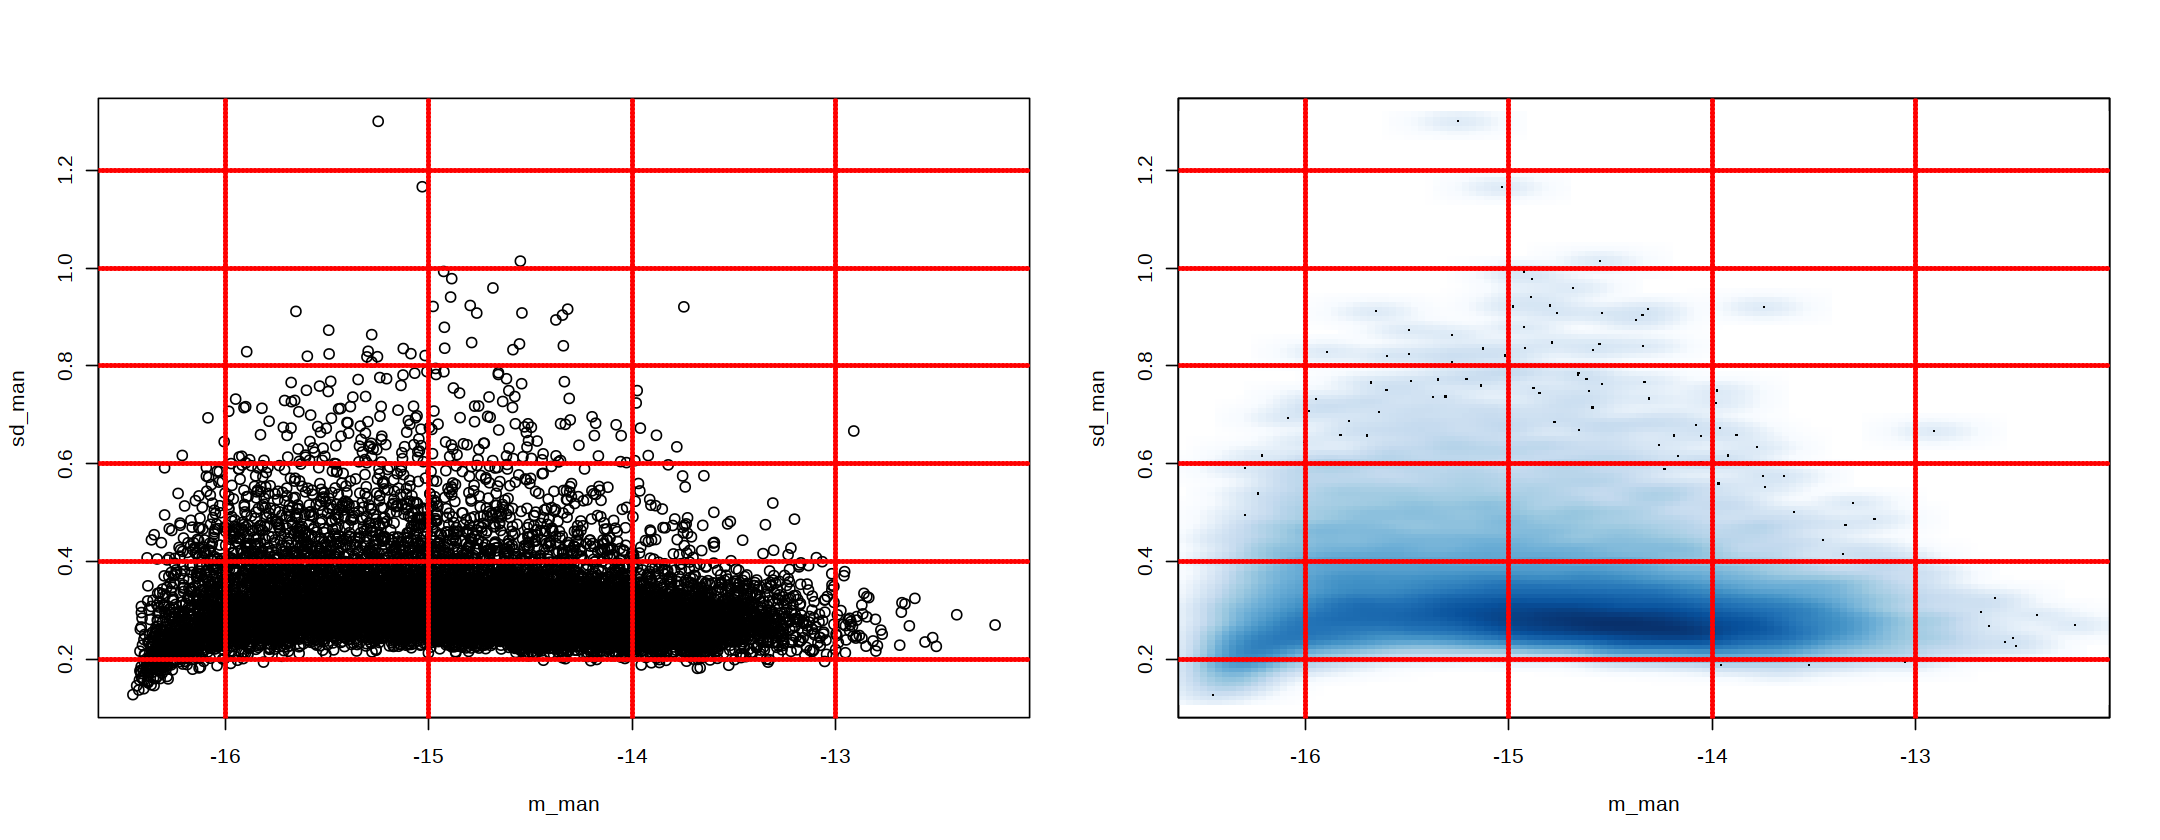

In [35]:
options(repr.plot.width = 18)
par(mfrow = c(1,2))
plot(m_man, sd_man)
grid(lwd = 3, col = 'red')
smoothScatter(m_man, sd_man)
grid(lwd = 3, col = 'red')

In [36]:
get_genes_specific_to_mcs <- function(legc, mc_pos = NULL, mc_neg = NULL, cl_vec = NULL) {
    if (!is.null(mc_pos) && is.null(mc_neg)) {
        cl_vec <- ifelse(1:ncol(legc) %in% mc_pos, 1, 0)
    } else if (!is.null(mc_pos) && !is.null(mc_neg)) {
        if (!(length(intersect(mc_pos, mc_neg)) == 0)) {
            stop('mc_pos and mc_neg intersect')
        }
        legc <- legc[,c(mc_pos, mc_neg)]
        cl_vec <- c(rep(1, length(mc_pos)), rep(0, length(mc_neg)))
    }
    legc_avg <- t(tgs_matrix_tapply(legc, cl_vec, mean))
    if (ncol(legc_avg) == 2) {
        diffs <- matrixStats::rowDiffs(legc_avg)
        rownames(diffs) <- rownames(legc_avg)
        return(diffs[order( diffs[,1], decreasing = T),])
    } else {
        diffs <- t(plyr::laply(1:ncol(legc_avg), function(i) legc_avg[,i] - matrixStats::rowMaxs(legc_avg[,-i]), .parallel = T))
        colnames(diffs) <- colnames(legc_avg)
        res <- lapply(1:ncol(diffs), function(i) {
            df <- diffs[which(diffs[,i] > 0.1),]
            return(df[order(df[,i], decreasing = T),])
        })
        names(res) <- colnames(legc_avg)
        return(res)
    }
}

In [37]:
ct_genes <- get_genes_specific_to_mcs(legc, cl_vec = mcmd$cell_type)

In [38]:
names(ct_genes) <- sort(unique(mcmd$cell_type))

In [39]:
ct_genes_vec <- do.call('c', purrr::imap(ct_genes, .f =function(.x,.y) setNames(rownames(.x), rep(.y, nrow(.x)))))
# ct_genes_vec <- unlist(lapply(ct_genes, rownames))

In [40]:
names(ct_genes_vec) <- gsub('\\..*', '', names(ct_genes_vec))

In [41]:
cts <- c('NSC', 'IPC', 'SCPN', 'CthPN', 'CPN_L2-3', 'CPN_L5_6')

In [42]:
# genes_prom_var <- rownames(day_mcl_prom)[intersect(which(sd_man >= 0.4), 
#                                                    which(rownames(day_mcl_prom) %in% unlist(lapply(ct_genes, function(x) head(rownames(x), 300)))))]

In [43]:
genes_prom_var <- unlist(lapply(ct_genes[cts], function(x) head(rownames(x)[rownames(x) %in% names(sd_man[which(sd_man >= 0.4)])], 50)))

In [44]:
sort(genes_prom_var)

IPC18           IPC23            IPC6         CthPN46           NSC44 
"9630028B13Rik"         "Acads"        "Adgrg1"         "Adrb1"         "Aif1l" 
           NSC6           NSC18           IPC32           IPC29          SCPN14 
        "Ajuba"        "Amotl2"        "Ankrd6"        "Antxr2"         "Aqp11" 
        CthPN12            IPC9           NSC39         CthPN44            IPC8 
     "Arhgap20"       "Arhgef2"          "Atf3"       "B3galt2"           "Bmf" 
         CthPN7            IPC2           IPC13      CPN_L5_616      CPN_L5_633 
       "Brinp1"        "Btbd17"        "C77080"       "Cacna1b"      "Cacna2d1" 
      CPN_L2-36          CthPN2         CthPN21           IPC11           NSC40 
       "Cacng2"         "Caln1"          "Caly"       "Ccdc136"         "Ccnd2" 
          IPC16         CthPN19          SCPN10           IPC27           NSC11 
       "Celsr1"          "Chl1"        "Churc1"         "Clvs1"         "Cmtm8" 
          NSC21           NSC45           IPC38           NSC20      CPN_L5_634 
      "Col18a1"        "Col2a1"          "Crb1"         "Creb5"         "Crhr1" 
          NSC12            NSC5           IPC17      CPN_L5_617         CthPN36 
        "Dach1"           "Dct"          "Dgkz"          "Dlg2"          "Dmtn" 
      CPN_L5_66           IPC20         CthPN30            IPC5           NSC15 
         "Dtx4"          "Dvl3"       "Dync1i1"        "Elavl4"          "Emx2" 
          NSC31         CthPN31           NSC33           NSC36           SCPN8 
        "Enkd1"         "Ephb1"         "Ephb4"          "Ermn"        "Fam13a" 
        CthPN35      CPN_L5_624           SCPN2           NSC38           IPC28 
      "Fam155a"        "Fbxo41"         "Fezf2"         "Fgfr3"        "Fibcd1" 
      CPN_L2-32           IPC14         CthPN32         CthPN14            NSC3 
          "Fn1"        "Frrs1l"           "Fry"        "Galnt9"          "Gas1" 
        CthPN41           NSC35          CthPN8         CthPN40         CthPN23 
         "Gas7"          "Gli3"        "Gm8773"          "Gnal"         "Gpr22" 
        CthPN50       CPN_L5_67         CthPN11         CthPN20         CthPN13 
        "Gpr26"         "Gria4"         "Grik3"         "Grip2"          "Grm3" 
        CthPN48      CPN_L5_615      CPN_L5_628         CthPN49           IPC33 
         "Grm5"          "Grm7"           "Grp"         "Hecw2"          "Heg1" 
           NSC1            NSC4          CthPN1      CPN_L5_614       CPN_L2-35 
         "Hes1"         "Hmga2"        "Hs3st4"         "Hspb3"        "Iqsec3" 
      CPN_L2-33            NSC2         CthPN42      CPN_L5_627      CPN_L5_611 
      "Jakmip1"          "Jph1"          "Jph3"          "Jph4"         "Kcnj2" 
          SCPN5         CthPN33      CPN_L5_613           SCPN1         CthPN16 
       "Kcnk12"        "Kcnma1"        "Kcnmb2"          "Ldb2"          "Lgi1" 
      CPN_L5_63         CthPN15          CthPN3      CPN_L5_630      CPN_L5_621 
       "Lingo2"          "Lmo7"           "Lpl"         "Lrrc7"        "Lrrtm1" 
        CthPN28         CthPN10           IPC10           NSC32           IPC30 
       "Lrrtm2"        "Lrrtm4"         "Ltbp3"         "Ltbp4"          "Mbd6" 
           NSC9          CthPN6            IPC4         CthPN18           NSC47 
         "Mcam"          "Meg3"         "Mfap4"          "Mgll"          "Mnd1" 
          NSC22            IPC3       CPN_L5_61           NSC17           IPC34 
        "Msrb3"          "Myt1"          "Nefl"           "Nes"        "Nfatc2" 
          IPC15       CPN_L5_65           IPC43           NSC26         CthPN26 
        "Nhlh1"         "Npy1r"         "Nr1h2"         "Nr4a2"          "Nrgn" 
          IPC24         CthPN29         CthPN17            IPC1      CPN_L5_622 
         "Nrn1"         "Nrxn1"         "Nyap2"        "Nynrin"         "Olfm2" 
         SCPN13           NSC23           NSC16           NSC48         CthPN43 
       "Olfml3"          "Pawr"          

In [1]:
length(genes_prom_var)

ERROR: Error in eval(expr, envir, enclos): object 'genes_prom_var' not found


In [574]:
# genes_prom_var <- rownames(day_mcl_prom)[head(rownames(x)[rownames(x) %in% which(sd_man >= 0.4) & rownames(x) %in% , 300)intersect(, 
#                                                    which(rownames(day_mcl_prom) %in% unlist(lapply(ct_genes, function(x) head(rownames(x), 300)))))]

In [46]:
names(genes_prom_var) <- names(ct_genes_vec)[match(genes_prom_var, ct_genes_vec)]

In [576]:
# day_mcl_prom <- t(do.call('rbind', 
#                     lapply(1:length(sc_cor_kms), 
#                             function(i) tgs_matrix_tapply(as.matrix(mat_prom@mat[,colnames(aaa$sc_res[[i]]$sc_cor)]), sc_cor_kms[[i]]$cluster, sum)
#                             )))

# nm <- "pl_prom_cort"

# gstat = scdb_gstat(nm)

# x = log(gstat$ds_mean)
# init_filt = which(x >= -4)
# y = gstat$ds_log_varmean[init_filt]
# name_filt = gstat$name
# x = x[init_filt]
# xcut = cut(x, breaks = seq(min(x), max(x), l = 50))
# top_q_inds = lapply(levels(xcut), function(l) {inds = which(xcut == l); 
#                                   xfilt = y[inds]; 
#                                   xtop = head(inds[order(xfilt, decreasing = T)], 30); 
#                                   return(xtop)
#                                  }
#       )

In [47]:
cor_mcl_mc <- tgs_cor(day_mcl_prom[genes_prom_var,] - rowMeans(day_mcl_prom[genes_prom_var,]), mc_rna@mc_fp[genes_prom_var,], spearman=T)

In [578]:
# cor_mcl_mc <- tgs_cor(a_legc_prom[genes_prom_var,], legc[genes_prom_var,], spearman=T)

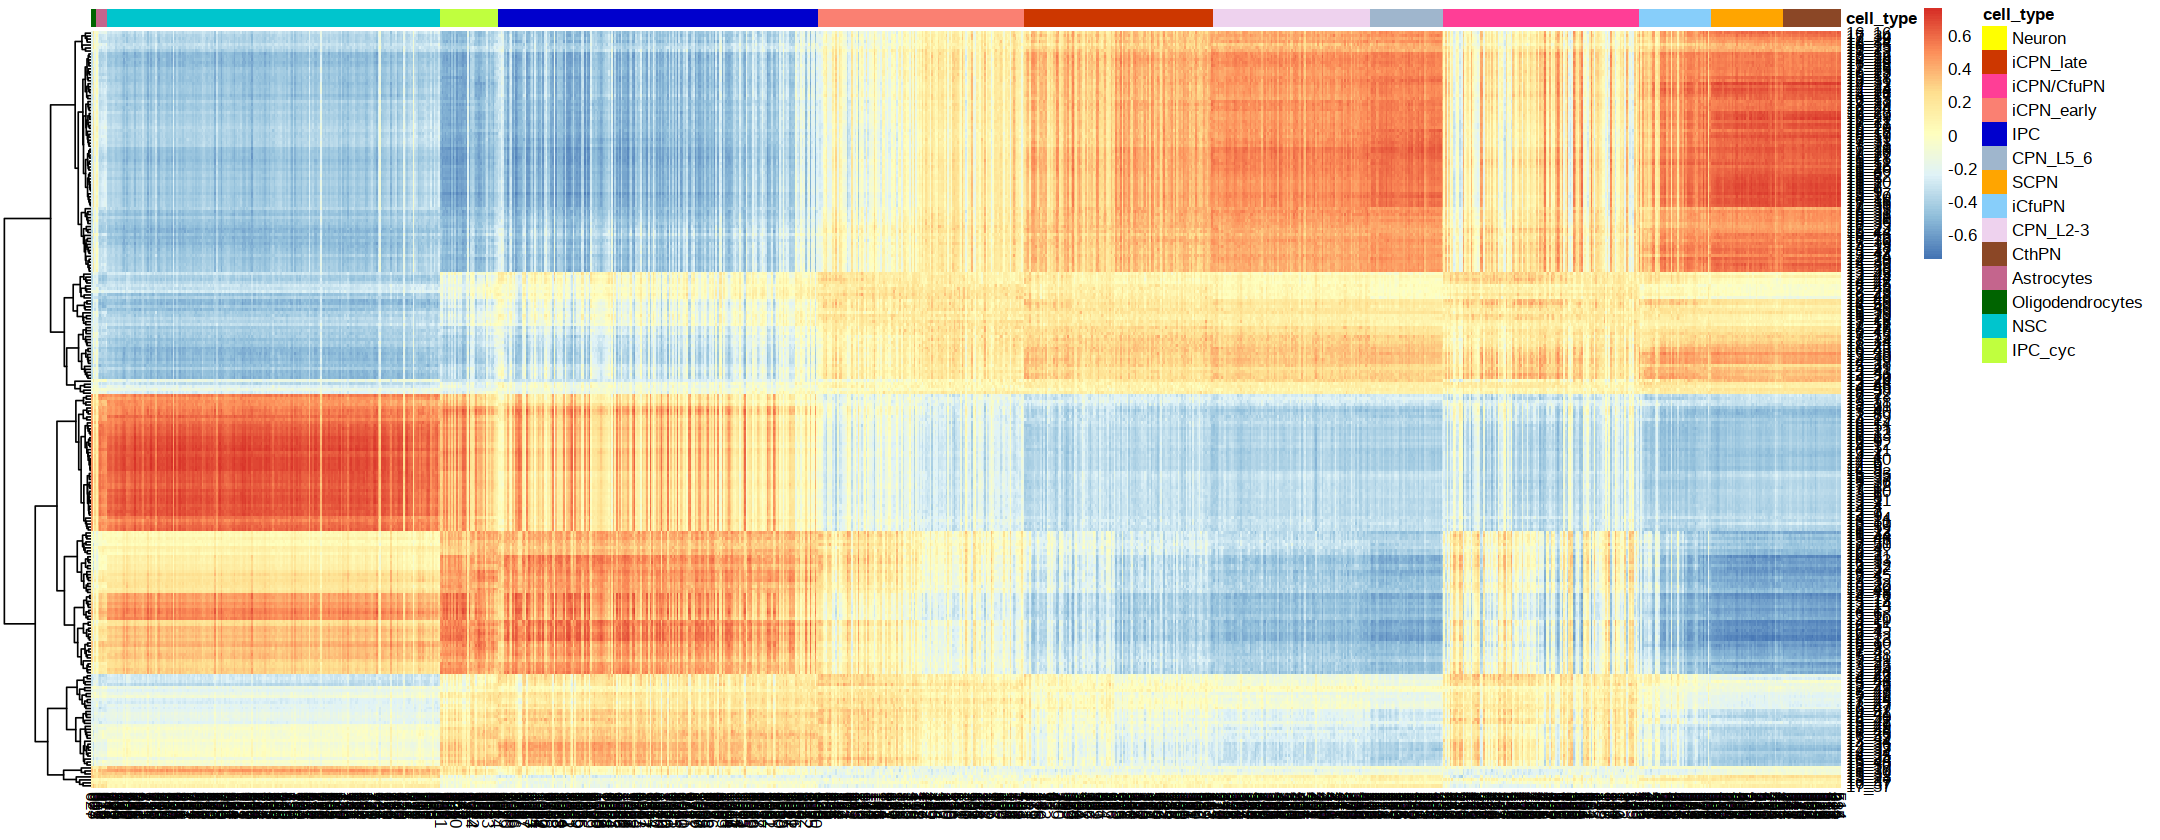

In [48]:
pheatmap(cor_mcl_mc[,cust_mc_ord_st], cluster_rows = T, cluster_cols = F, annotation_col = col_annot, annotation_colors = ann_colors, 
         # color = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-.3,.3,l=100)
        )

In [267]:
# gb <- intersect(rownames(day_mcl_prom), rownames(mc_rna@mc_fp))

# cor_mcl_mc <- tgs_cor(day_mcl_prom[gb,], mc_rna@mc_fp[gb,], spearman=T)

# pheatmap(cor_mcl_mc[,cust_mc_ord_st], cluster_rows = T, cluster_cols = F, annotation_col = col_annot, annotation_colors = ann_colors, 
#          # color = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-.3,.3,l=100)
#         )

In [211]:
# saveRDS(day_mcls, day_mcl_path)

In [49]:
days_in_rownames <- unlist(purrr::map(stringr::str_split(rownames(cor_mcl_mc), '_'),1))

In [295]:
# for (d in unique(days_in_rownames)) {
#     day_mcls[[d]]$cor_amc_rmc <- cor_mcl_mc[days_in_rownames == d,]
# }

In [416]:
sc_cor_kms <- readRDS('~/raid/proj/mmcortex/output/mcatac/amc_assignment_w_non_cort_colsums_6e3_6e3_k=100.RDS')

In [419]:
load('~/raid/proj/mmcortex/output/mcatac/scatac_sc_cors_per_day_filter_colsums_6e3_6e4.rda')

In [50]:
day_mcls <- lapply(unique(days_in_rownames), function(d) {
    return(list(cor_amc_rmc = cor_mcl_mc[days_in_rownames == d,]))
})
names(day_mcls) <- unique(days_in_rownames)

In [582]:
day_mcl_path

[1] "/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex//output/mcatac/pl_cort_day_mcls_test.rds"

In [318]:
saveRDS(day_mcls, file = '/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex//output/mcatac/pl_cort_day_mcls_test.rds')

In [293]:
# day_mcls <- readRDS(day_mcl_path)

In [294]:
# cor_mcl_mc <- do.call('rbind', lapply(day_mcls, function(x) x$cor_amc_rmc))
# tgs_cor(day_mcl_prom[genes_prom_var,], mc_rna@mc_fp[genes_prom_var,], spearman=T)

In [51]:
# names(top_q_inds) = levels(xcut)
# mc_rna <- scdb_mc('pl_cort')
# feats = intersect(rownames(gstat)[init_filt[unlist(top_q_inds)]], rownames(mc_rna@mc_fp))
# cor_mcl_mc <- tgs_cor(day_mcl_prom[feats,], mc_rna@mc_fp[feats,], spearman=T)
# rownames(cor_mcl_mc) <- sapply(13:18, function(x) paste0(x, '_', 1:K))

order_columns_hc_com <- function(mat, hc_cut_deg) {
    hcm <- hclust(dist(t(mat)), method = 'ward.D2')
    hc_ct <- cutree(hcm, hc_cut_deg)
    com_hc <- sapply(unique(hc_ct), function(ci) {
                    # print(dim(mat[,hc_ct == ci]))    
                    if (!is.null(dim(mat[,hc_ct == ci]))) {
                            vec <- rowMeans(mat[,hc_ct == ci]); 
                        } else {
                            vec <- mat[,hc_ct == ci]; 
                        }
                        # print(quantile(vec))
                        return(sum(vec*1:length(vec))/sum(vec))
                        })
    # print(com_hc)
    ord <- as.numeric(do.call('c', lapply(unique(hc_ct)[order(com_hc)], function(ci) which(hc_ct == ci))))
    # print(length(ord))
    # print(ord)
    return(ord)
}

In [52]:
amc_st_assn <- mcmd$cell_type[apply(cor_mcl_mc, 1, which.max)]
amc_cat_assn <- ifelse(amc_st_assn %in% c('NSC', 'IPC', 'IPC_cyc', 'Astrocytes', 'OPCs'), amc_st_assn, 'Neuron')
amc_cat_assn <- ifelse(amc_st_assn %in% c('Astrocytes', 'OPCs'), 'NSC', amc_cat_assn)
amc_ord <- do.call('c', lapply(c('NSC' ,'IPC', 'Neuron'), function(ct) {
    vec <- which(amc_cat_assn == ct);
    com_ord <- order_columns_hc_com(t(cor_mcl_mc[vec,]), 5);
    return(setNames(vec[com_ord], rep(ct, length(vec))))
    }))

In [53]:
row_annot <- as.data.frame(amc_cat_assn)

In [54]:
rownames(row_annot) <- colnames(mcl_all_norm)

In [55]:
colnames(row_annot) <- 'cell_type'

In [56]:
ann_colors = list('cell_type' = setNames(unique(mcmd$color), unique(mcmd$cell_type)))
ann_colors[['cell_type']] <- c(ann_colors[['cell_type']], setNames('yellow', 'Neuron'))

In [57]:
mean_prom_ct <- t(tgs_matrix_tapply(t(log2(1e-5+day_mcl_prom[genes_prom_var,])), names(genes_prom_var), mean))

In [58]:
prom_cl_ct <- log2(1e-5+t(day_mcl_prom[genes_prom_var,]))

In [59]:
options(repr.plot.height = 10)
options(repr.plot.width = 10)

In [60]:
row_annot_feature_promoters <- tibble::enframe(genes_prom_var, value = 'gene', name = 'cell_type')  %>% tibble::column_to_rownames('gene')

[1] -1.697057
[1] 1.448833


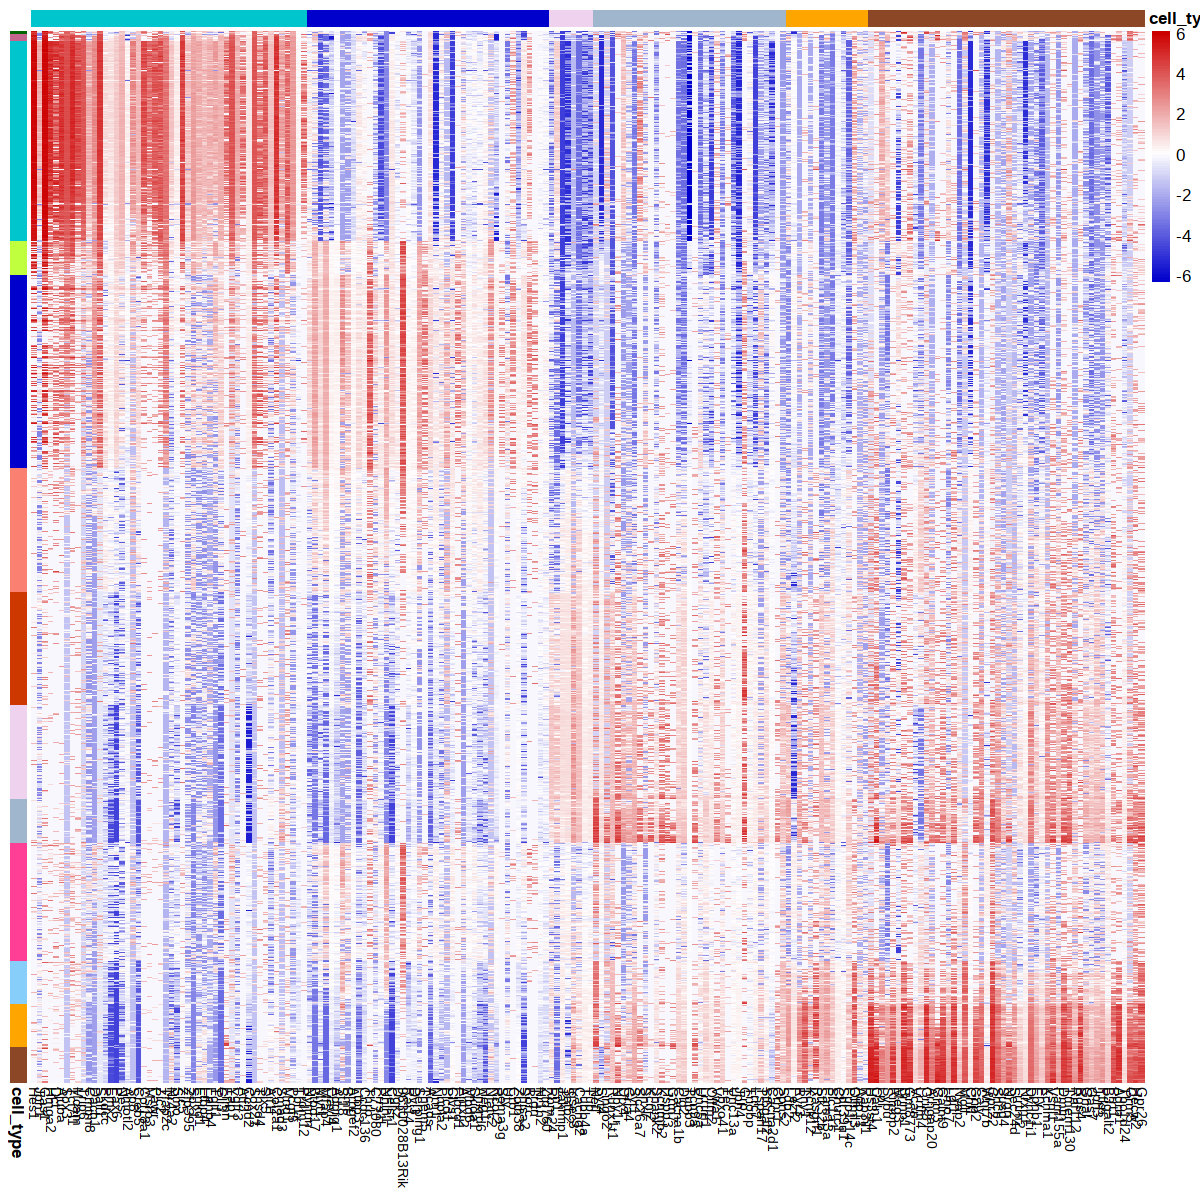

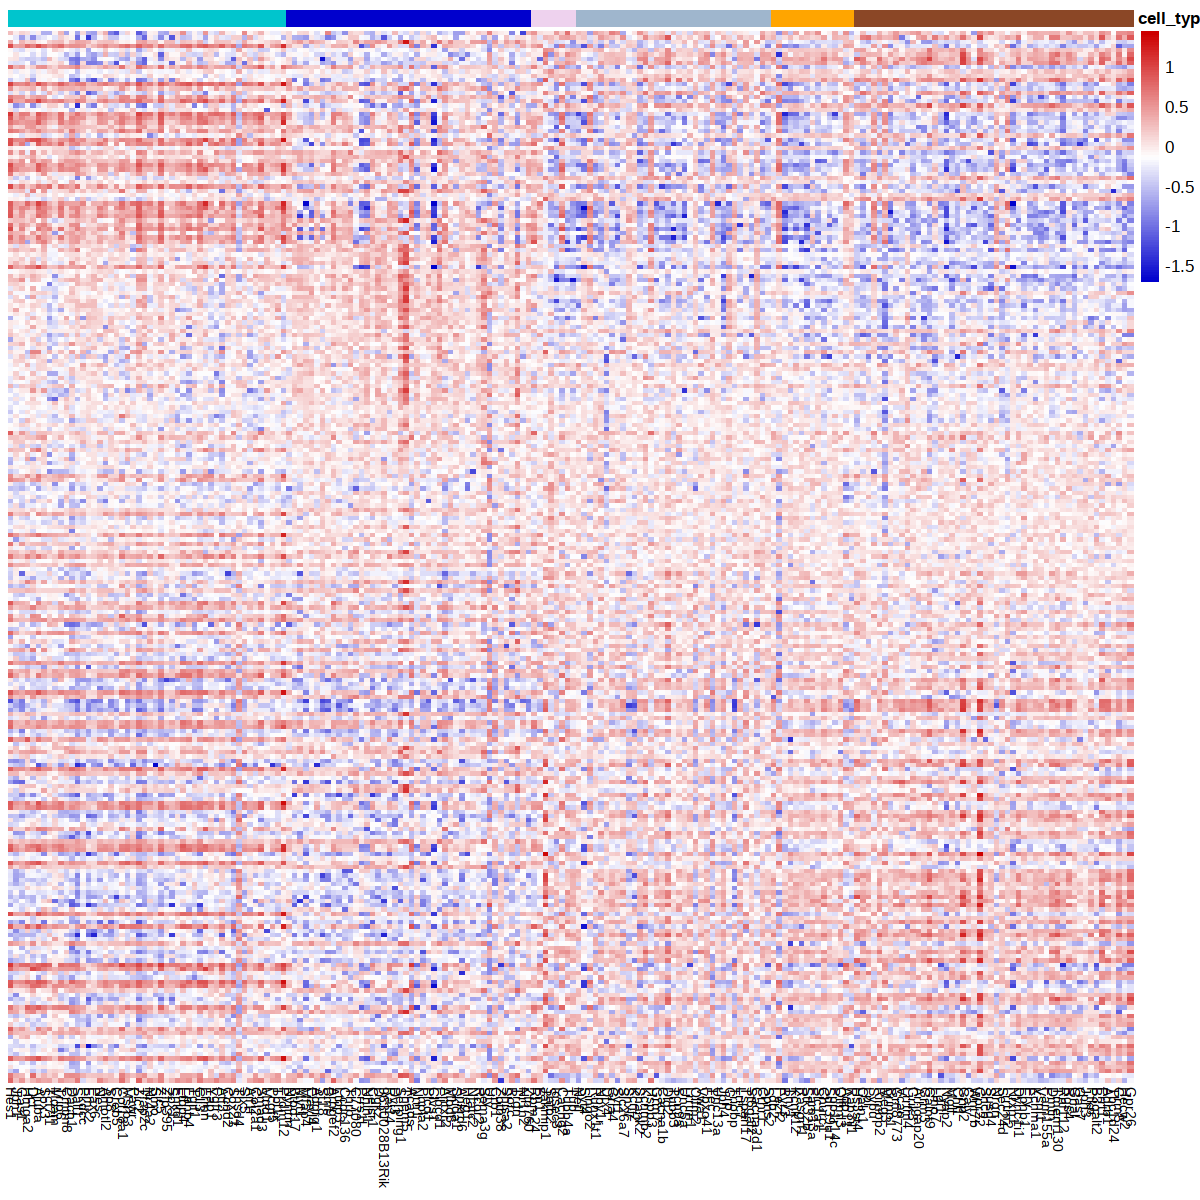

In [61]:
# pa <- pheatmap(log2(1e-5+day_mcl_prom[genes_prom_var,amc_ord]), cluster_rows = F, cluster_cols = F)
# pr <- pheatmap(legc[genes_prom_var[pa$tree_row$order],cust_mc_ord_st], cluster_rows = T, cluster_cols = F)
eps <- 1e-1
pltmt <- apply(t(legc[genes_prom_var[order(match(names(genes_prom_var), cust_st_ord))],cust_mc_ord_st]), 2, function(x) log2((eps + x - min(x))/(median(eps + x - min(x)))))
# pltmt <- t(legc[genes_prom_var[order(match(names(genes_prom_var), cust_st_ord))],cust_mc_ord_st])
minvr <- min(pltmt)
maxvr <- max(pltmt)
brks <- c(seq(minvr, 0, l = 50), seq(eps,maxvr,l=51))
clrmp <- colorRampPalette(c('blue3', 'white', 'red3'))(100)
pr <- pheatmap(pltmt, 
               fontsize_col = 8, show_rownames = F, 
               color = clrmp, breaks = brks,
               annotation_col = row_annot_feature_promoters,
               annotation_legend = F,
               cluster_rows = F, 
               cluster_cols = F, 
               annotation_row = col_annot, annotation_colors = ann_colors)
eps <- 1

pltmt <- apply(t(log2(1e-5+day_mcl_prom[genes_prom_var[order(match(names(genes_prom_var), cust_st_ord))],amc_ord])), 2, 
               function(x) log2((eps + x - min(x))/(median(eps + x - min(x)))))

# pltmt <- t(log2(1e-5+day_mcl_prom[genes_prom_var[order(match(names(genes_prom_var), cust_st_ord))],amc_ord]))
minvr <- min(pltmt)
maxvr <- max(pltmt)
print(minvr)
print(maxvr)               
# brks <- c(seq(minvr, 0, l = 50), seq(eps,maxvr,l=51))
ord <- order(apply(pltmt, 1, function(x) sum(x*1:length(x))/sum(x)), decreasing = T)
pa <- pheatmap(pltmt[ord,],  fontsize_col = 8, show_rownames = F,treeheight_row = 0.5,
               color = clrmp,
               # breaks = brks,
               cluster_rows = F, cluster_cols = F,annotation_legend = F,
               annotation_col = row_annot_feature_promoters,annotation_colors = ann_colors)

In [190]:
save_pheatmap(pr, './output/mcatac/figs/rna_of_feature_promoters.png', h = 1800, w = 4000, res = 250)
save_pheatmap(pa, './output/mcatac/figs/atac_of_feature_promoters.png', h = 1800, w = 4000, res = 250)

png 
  2

png 
  2

In [109]:
options(repr.plot.height = 14)
options(repr.plot.width = 14)

In [110]:
ca_pcc <- tibble::column_to_rownames(tibble::enframe(genes_prom_var, value = 'gene', name = 'cell_type'), 'gene')

In [119]:
gpv_ord <- unlist(sapply(cust_st_ord, function(cti) genes_prom_var[names(genes_prom_var)  == cti]))

In [122]:
gv <- which(names(gpv_ord)[1:(length(gpv_ord)-1)] != names(gpv_ord)[2:length(gpv_ord)])

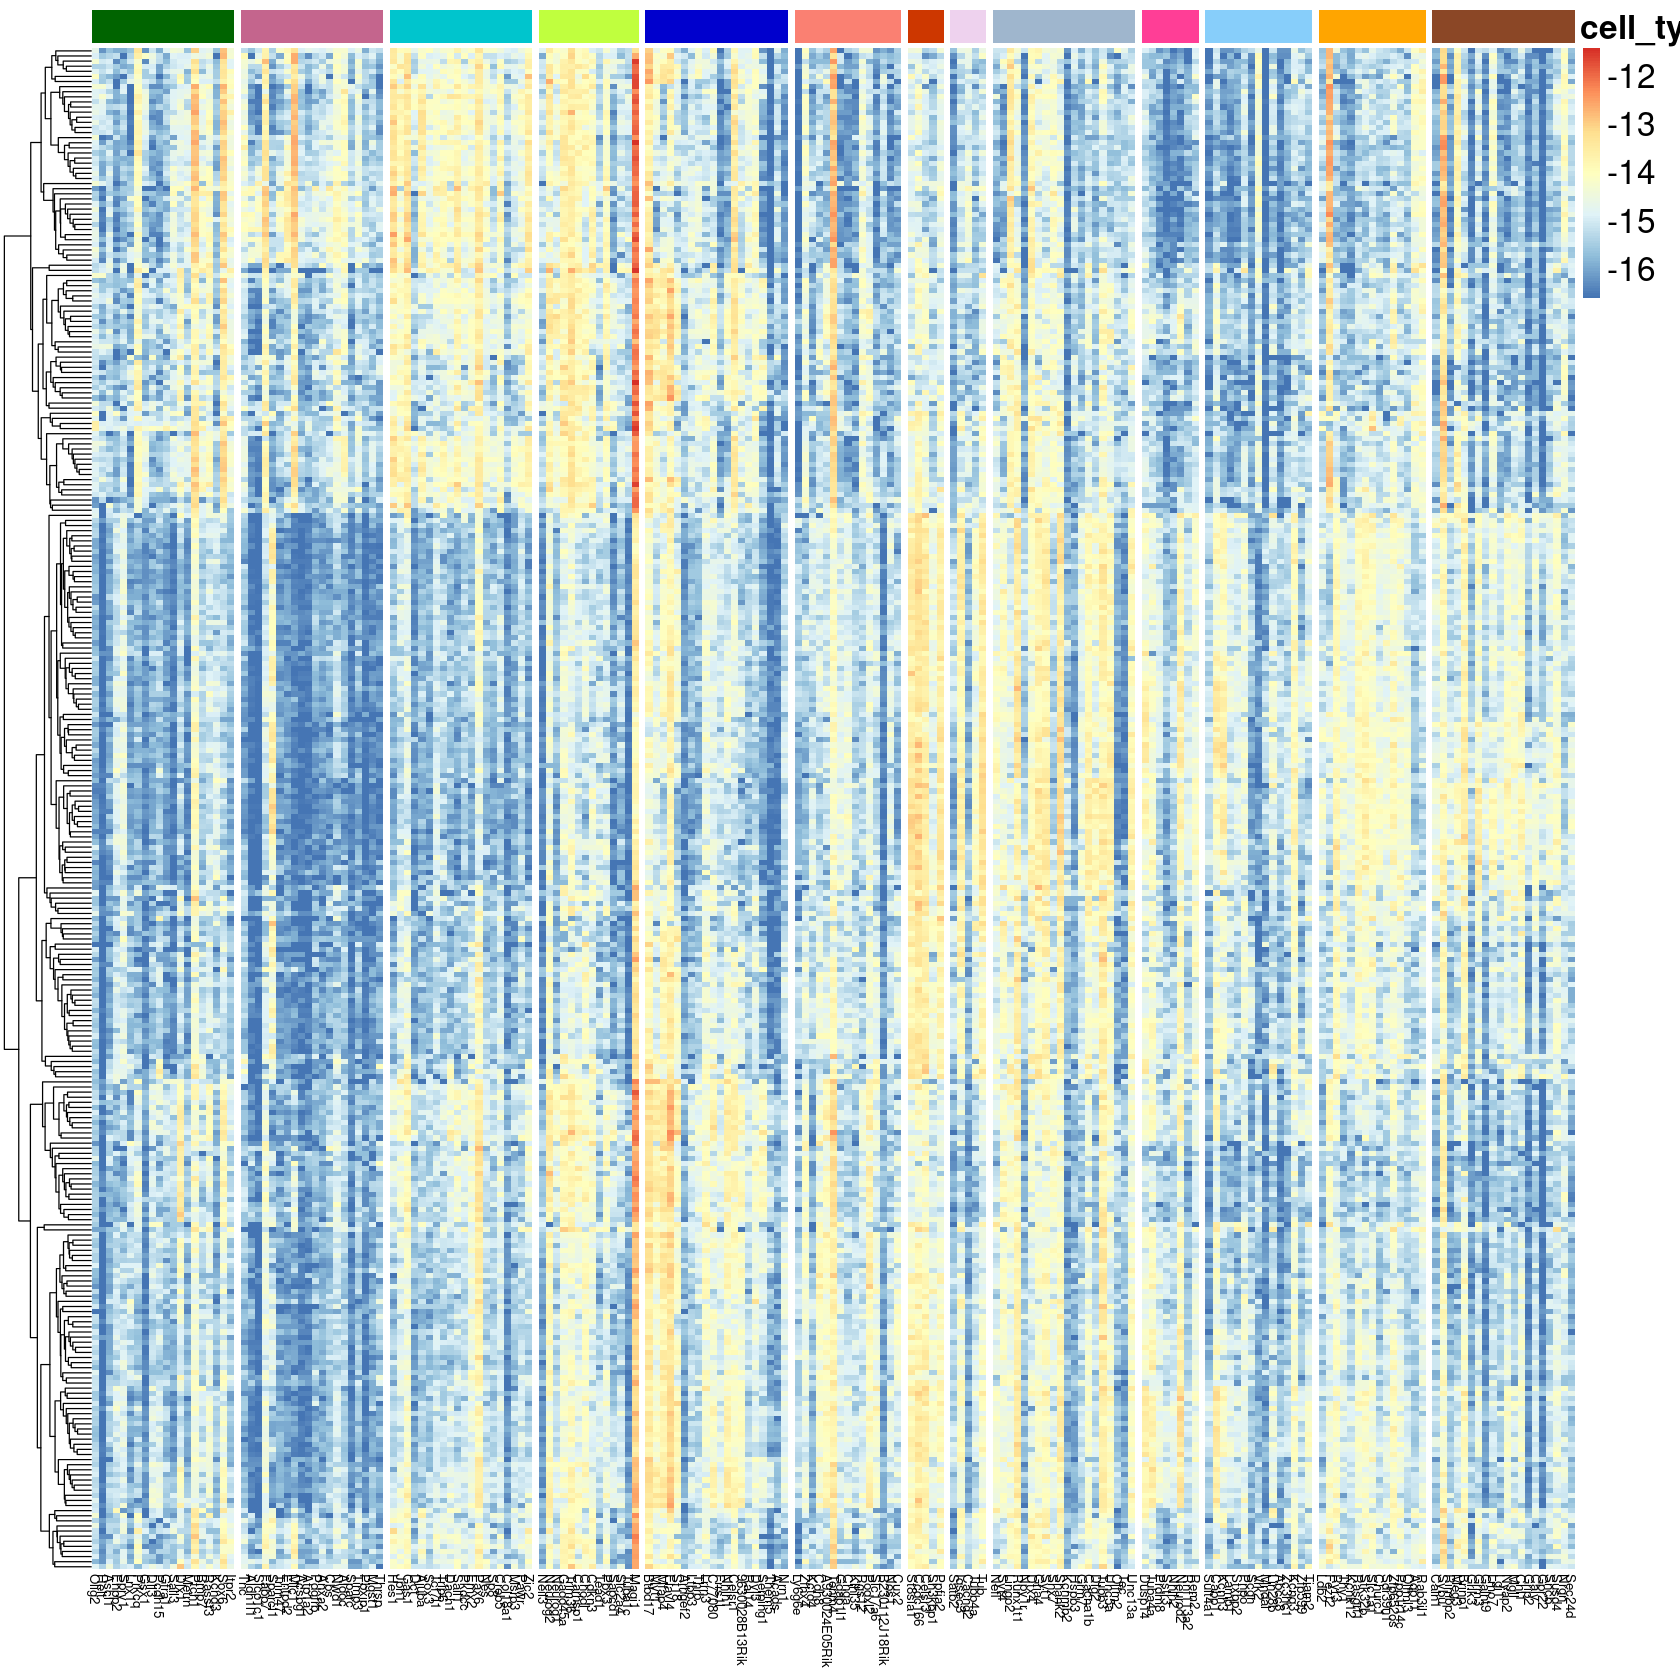

In [130]:
p_amc_on_prom_clusters <- pheatmap(prom_cl_ct[amc_ord,gpv_ord], fontsize_col = 8, annotation_legend = F, 
                                   gaps_col = gv, cluster_cols = F,
                                                                    annotation_col = ca_pcc, annotation_colors = ann_colors, 
                                                                    cluster_rows = T,  show_colnames = T, show_rownames = F, fontsize = 20)

In [43]:
options(repr.plot.width = 14)
options(repr.plot.height = 18)

In [44]:
dim(day_mcl_prom)

[1] 12921   300

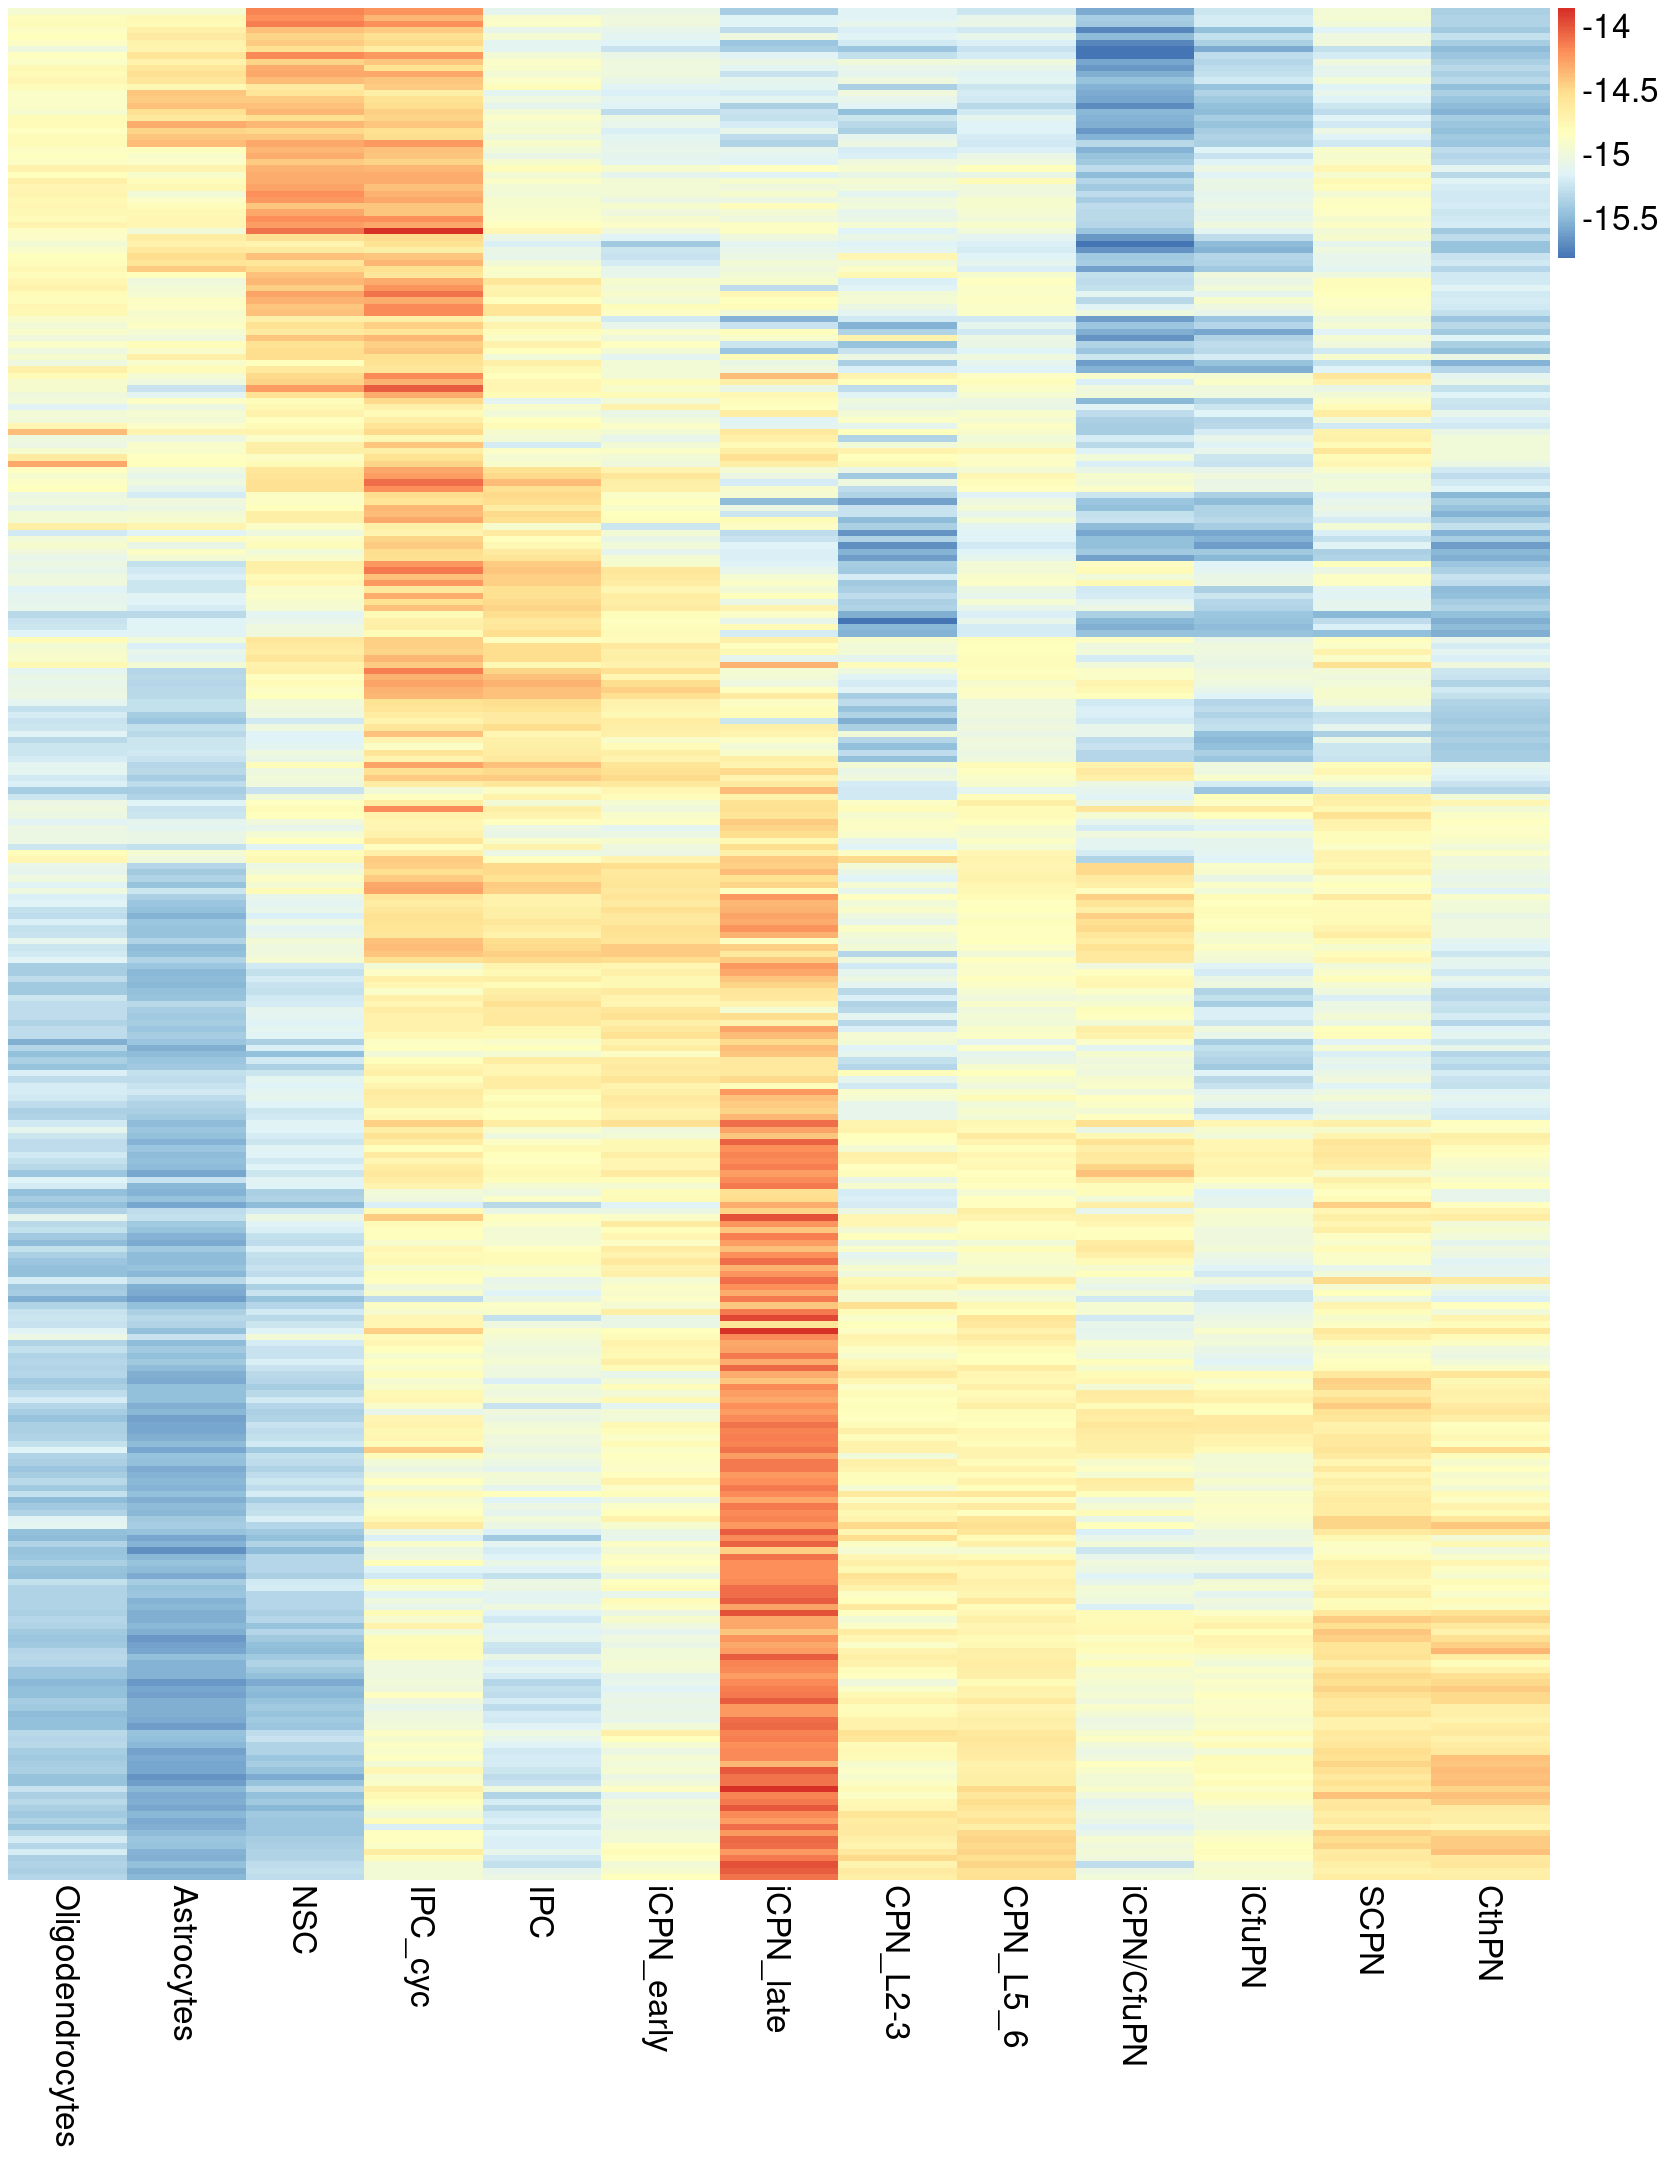

In [40]:
p_amc_on_prom_clusters <- pheatmap(mean_prom_ct[amc_ord,cust_st_ord], cluster_rows = F, cluster_cols = F, show_colnames = T, show_rownames = F, fontsize = 20)

In [131]:
save_pheatmap(p_amc_on_prom_clusters, './output//mcatac/figs/amc_on_prom_clusters.png', h = 1600, w = 2400, res = 150)

png 
  2

In [275]:
# save(row_annot, amc_ord, ann_colors, file = './output/mcatac/atac_metacell_order_annotation.rda')

In [62]:
ann_colors[['cell_type']] <- c(setNames('yellow','Neuron'), ann_colors[['cell_type']])

In [63]:
ann_colors

$cell_type
          Neuron        iCPN_late       iCPN/CfuPN       iCPN_early 
        "yellow"        "#CD3700"        "#FF3E96"        "#FA8072" 
             IPC         CPN_L5_6             SCPN           iCfuPN 
       "#0000CD"        "#9FB6CD"        "#FFA500"        "#87CEFA" 
        CPN_L2-3            CthPN       Astrocytes OPCs 
       "#EED2EE"        "#8B4726"        "#C4658D"        "#006400" 
             NSC          IPC_cyc           Neuron 
       "#00C5CD"        "#C0FF3E"         "yellow"

In [172]:
feats <- names(scdb_gset('pl_f')@gene_set)

In [175]:
gb <- intersect(feats, intersect(rownames(day_mcl_prom), rownames(mc_rna@mc_fp)))

In [176]:
length(gb)

[1] 1332

In [177]:
cor_mcl_mc <- tgs_cor(day_mcl_prom[gb,] - rowMeans(day_mcl_prom[gb,]), mc_rna@mc_fp[gb,], spearman=T)

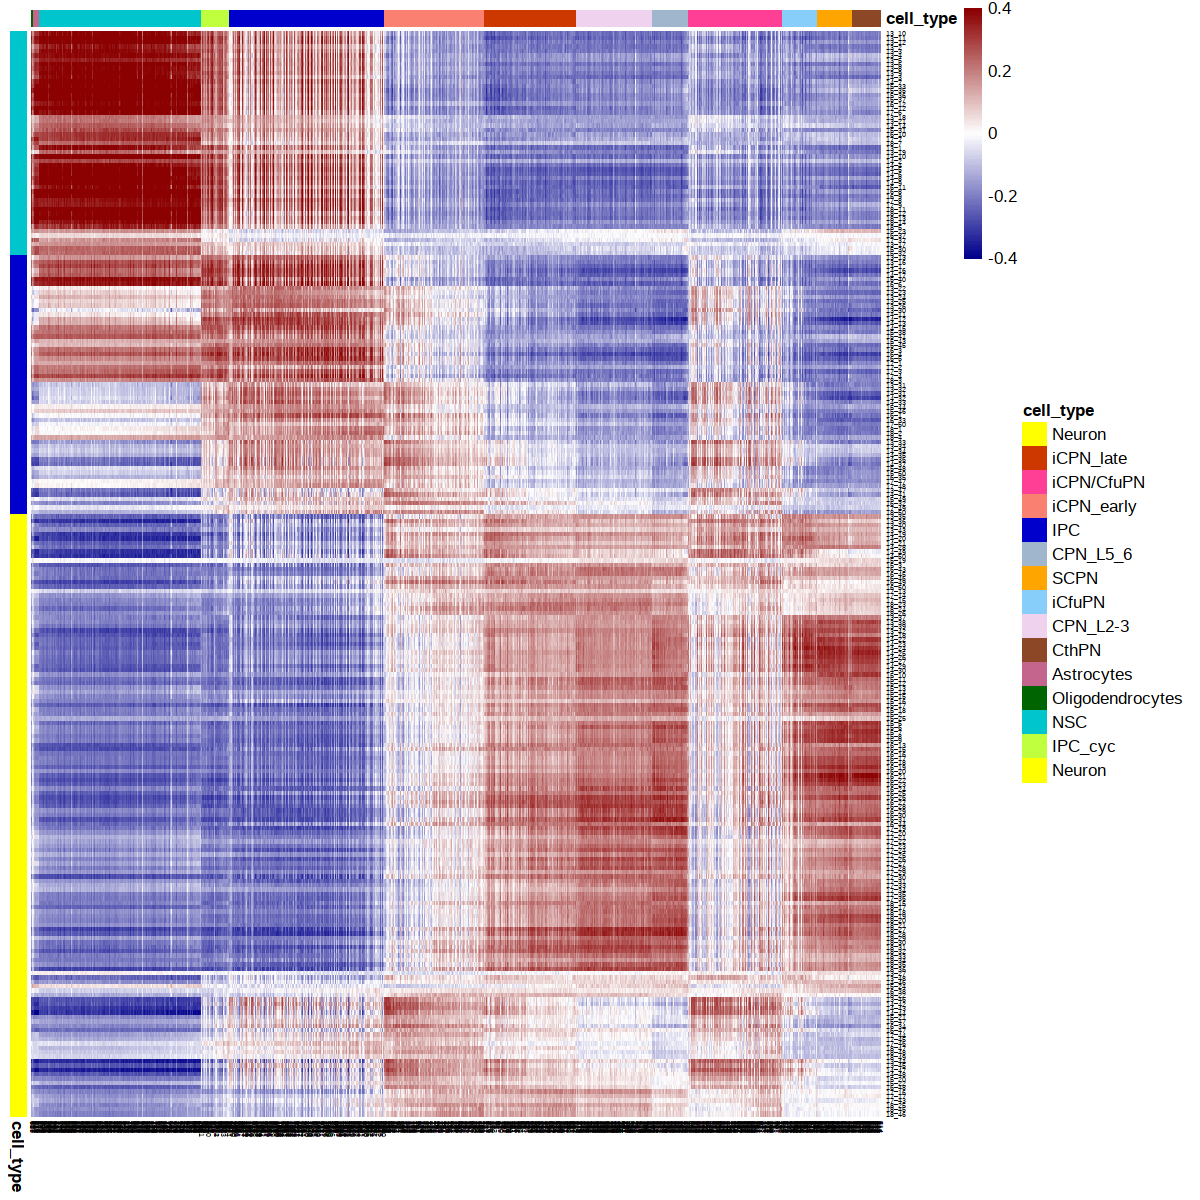

In [178]:
pltmt <- cor_mcl_mc
rownames(pltmt) <- colnames(mcl_all)

p_cor_mcl_mc_order <- pheatmap(pltmt[amc_ord,cust_mc_ord_st], 
                                    color = colorRampPalette(c('blue4', 'white', 'red4'))(100),
                                    breaks = seq(-.4,.4, l = 101),
                                    cluster_cols = F, 
                               cluster_rows = F,
                                     annotation_col = col_annot, annotation_row = row_annot,
                                     annotation_colors = ann_colors, 
                                     fontsize_row = 4, fontsize_col = 4)

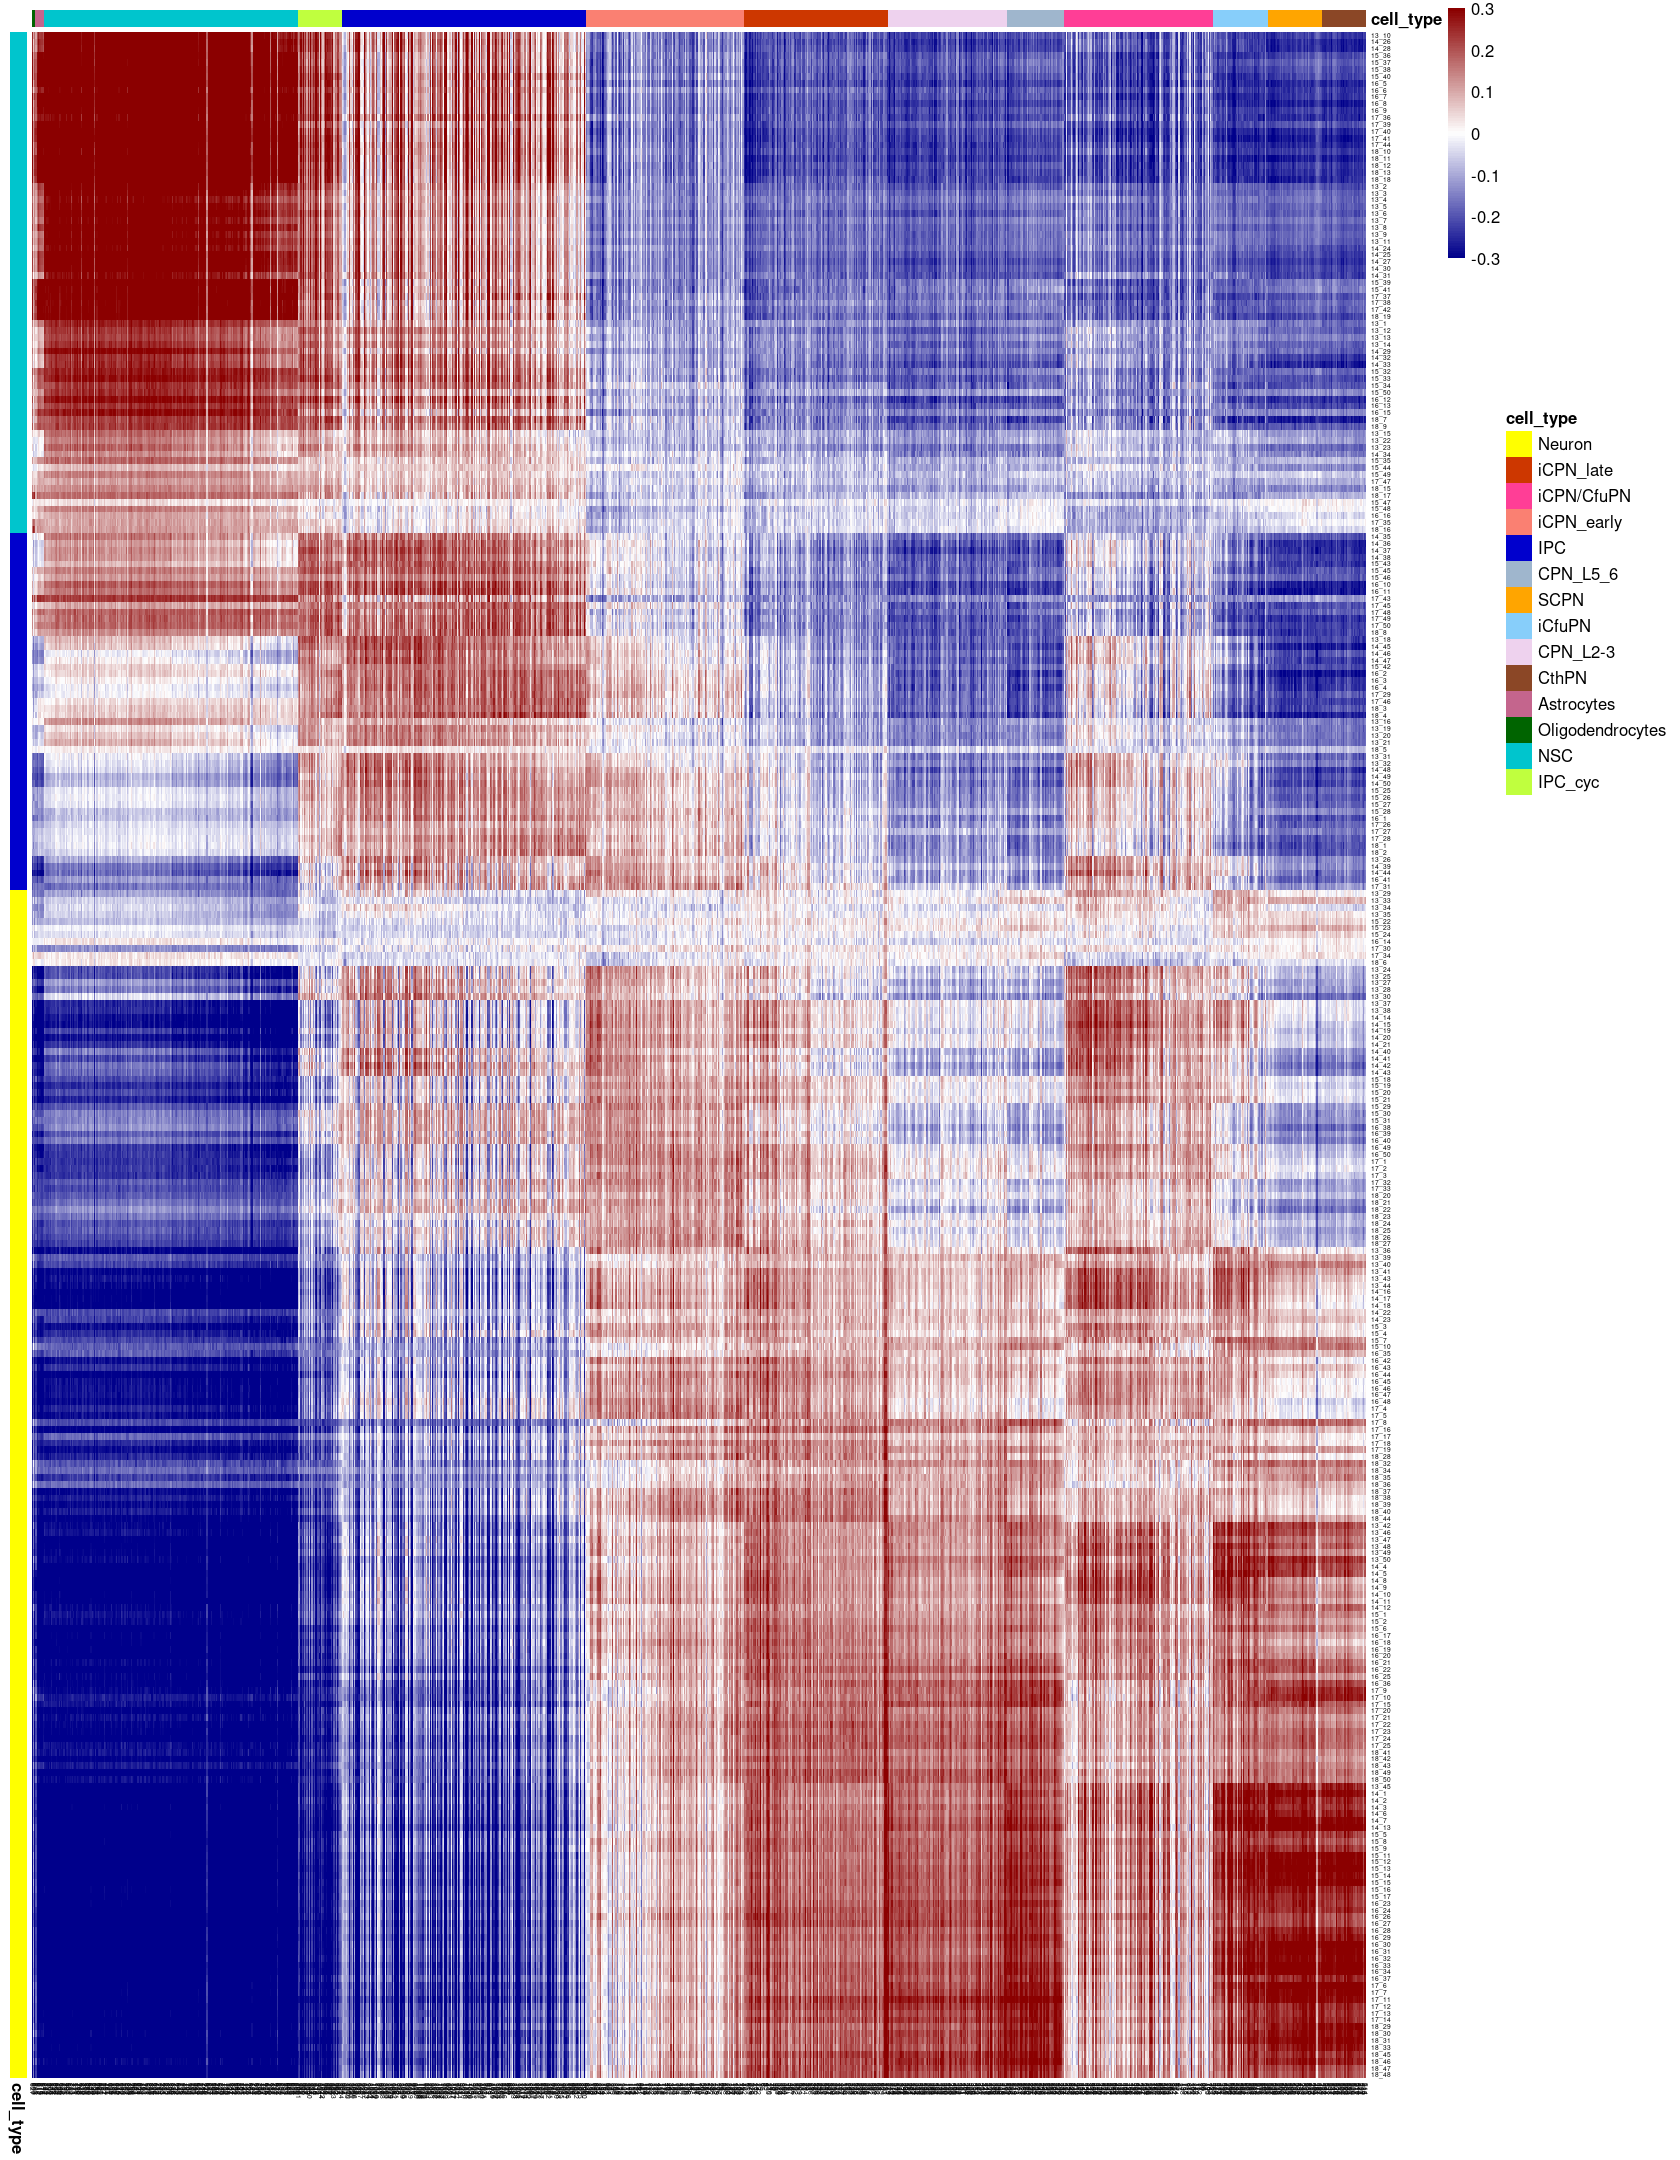

In [51]:
pltmt <- cor_mcl_mc
rownames(pltmt) <- colnames(mcl_all)

p_cor_mcl_mc_order <- pheatmap(pltmt[amc_ord,cust_mc_ord_st], 
                                    color = colorRampPalette(c('blue4', 'white', 'red4'))(100),
                                    breaks = seq(-.3,.3, l = 101),
                                    cluster_cols = F, 
                               cluster_rows = F,
                                     annotation_col = col_annot, annotation_row = row_annot,
                                     annotation_colors = ann_colors, 
                                     fontsize_row = 4, fontsize_col = 4)

In [ ]:
km_a_legc <- tglkmeans::TGL_kmeans(as.matrix(a_legc), k = K_PEAK_CLUST)

load("/net/mraid14/export/tgdata/users/atanay/proj/mmcortex/work0922/data/atac_clsts_mmcortex.Rda",v=T)
old_clust_vec <- atac_clsts$km$cluster[atac_clsts$km$cluster %in% atac_clsts$vclst_nms]

## Run matching

In [296]:
# days_in_rownames <- unlist(purrr::map(stringr::str_split(rownames(cor_mcl_mc), '_'),1))

In [297]:
# day_mcls <- lapply(unique(days_in_rownames), function(d) cor_mcl_mc[days_in_rownames == d,])
# names(day_mcls) <- unique(days_in_rownames)

In [161]:
NUM_EDGE_NODE

[1] 10

In [1]:
ls()

character(0)

In [180]:
make_mcl_mc_edges = function(d, cor_mic_cl) {
    edge_inds_mc_avail = which(mcmd[,paste0('E', d)] > 0)
    # print(edge_inds_mc_avail)
    edge_inds_mc = t(apply(cor_mic_cl, 2, function(x) {
                        head(order(x, decreasing = T), NUM_EDGE_NODE)
    }))
    edge_inds_mcl = t(apply(cor_mic_cl, 1, function(x) {
                                                        cor_vec = x[edge_inds_mc_avail];
                                                        inds_in_vec = head(order(cor_vec, decreasing = T), NUM_EDGE_NODE)
                                                        inds = edge_inds_mc_avail[inds_in_vec];
                                                        return(inds)
                                                        }
                           )
                     )

    edge_mat = matrix(0,nrow(cor_mic_cl),ncol(cor_mic_cl))

    edge_mat_mc = sapply(seq_along(1:ncol(edge_mat)), function(em, ei, i) {tmp = em[,i];
                                                                           tmp[ei[i,]] = 1;
                                                                          return(tmp)}, em = edge_mat, ei = edge_inds_mc)
    edge_mat_mc[,!(1:ncol(edge_mat_mc) %in% edge_inds_mc_avail)] = 0
    edge_mat_mcl = t(sapply(seq_along(1:nrow(edge_mat)), function(em, ei, i) {tmp = em[i,];
                                                                           tmp[ei[i,]] = 1;
                                                                          return(tmp)}, em = edge_mat, ei = edge_inds_mcl))
    
    print(quantile(colSums(edge_mat_mcl)))
    print(quantile(rowSums(edge_mat_mc)))
    edge_mat_all = edge_mat_mc + edge_mat_mcl
    edge_mat_all[edge_mat_all > 1] = 1
    csi <- which(colSums(edge_mat_all) >= NUM_EDGE_NODE)
    rsi <- which(rowSums(edge_mat_all) >= NUM_EDGE_NODE)
    dsc <- scm_downsamp(edge_mat_all[,csi], NUM_EDGE_NODE)
    dsr <- scm_downsamp(t(edge_mat_all[rsi,]), NUM_EDGE_NODE)
    ema_c <- edge_mat_all
    ema_c[,csi] <- as.matrix(dsc)
    ema_r <- edge_mat_all
    ema_r[rsi,] <- t(as.matrix(dsr))
    dsa <- as.matrix(ema_c) + as.matrix(ema_r)
    edge_mat_all <- dsa
    edge_mat_all[edge_mat_all > 1] = 1
    edge_inds = which(edge_mat_all == 1)
    edge_vals = cor_mic_cl[edge_inds]

    row_inds = matrix(rep(1:nrow(cor_mic_cl), ncol(cor_mic_cl)), nrow(cor_mic_cl), ncol(cor_mic_cl))
    col_inds = matrix(rep(1:ncol(cor_mic_cl), nrow(cor_mic_cl)), nrow(cor_mic_cl), ncol(cor_mic_cl), byrow = T)

    edge_inds_row = row_inds[edge_inds]
    edge_inds_col = col_inds[edge_inds]
    print(dim(edge_mat_all))
    # print(quantile(colSums(edge_mat_all)))
    # print(quantile(rowSums(edge_mat_all)))
    return(list('edge_mat_all' = edge_mat_all, 'edge_inds' = edge_inds, 'edge_vals' = edge_vals, 
                'edge_inds_row' = edge_inds_row, 'edge_inds_col' = edge_inds_col))
}

day_edges_all = lapply(seq_along(1:length(day_mcls)), function(d, dm, i) {make_mcl_mc_edges(d[[i]], dm[[i]]$cor_amc_rmc)}, d = names(day_mcls), dm = day_mcls)

  0%  25%  50%  75% 100% 
   0    0    0    0   13 
    0%    25%    50%    75%   100% 
  0.00  78.75 122.50 147.50 217.00 
[1]   44 1093
  0%  25%  50%  75% 100% 
   0    0    0    0   10 
  0%  25%  50%  75% 100% 
   6  111  145  191  232 
[1]   46 1093
  0%  25%  50%  75% 100% 
   0    0    0    0   11 
    0%    25%    50%    75%   100% 
  3.00 154.25 221.00 265.25 358.00 
[1]   42 1093
  0%  25%  50%  75% 100% 
   0    0    0    0   15 
  0%  25%  50%  75% 100% 
   1  128  188  247  360 
[1]   43 1093
  0%  25%  50%  75% 100% 
   0    0    0    0   16 
    0%    25%    50%    75%   100% 
 13.00 112.75 174.00 239.50 327.00 
[1]   40 1093
  0%  25%  50%  75% 100% 
   0    0    0    0   13 
   0%   25%   50%   75%  100% 
 12.0 101.5 137.0 188.0 299.0 
[1]   39 1093


In [159]:
edge_mat_alli <- do.call('rbind', lapply(day_edges_all, function(x) x$edge_mat_all))

In [155]:
quantile(colSums(edge_mat_all))

0%  25%  50%  75% 100% 
  10   30   40   40   60

In [156]:
quantile(rowSums(edge_mat_all))

0%   25%   50%   75%  100% 
 10.0 112.0 155.5 213.0 357.0

In [154]:
dim(edge_mat_all)

[1]  254 1093

In [181]:
edge_vals = unlist(sapply(day_edges_all, function(x) x$edge_vals))

cor_mic_cl = do.call("rbind", lapply(day_mcls, function(x) x$cor_amc_rmc))

edge_inds_row = do.call("c", lapply(seq_along(1:length(day_edges_all)), 
                                                        # function(dea,K,i) {return(dea[[i]]$edge_inds_row + (i-1)*K)}, 
                                                        #                     dea = day_edges_all, 
                                                        #                     K = K_CL_PER_DAY
                                                                                            function(dea,i) {return(match(rownames(day_mcls[[i]]$cor_amc_rmc[dea[[i]]$edge_inds_row,]), 
                                                                                                                           rownames(cor_mcl_mc)))}, 
                                                                            dea = day_edges_all
                                                                            # K = K_CL_PER_DAY
                                   )
                       )

edge_inds_col = do.call("c", lapply(day_edges_all, function(x) x$edge_inds_col))


num_edges = length(edge_vals)
N = nrow(cor_mic_cl)
M = ncol(cor_mic_cl)
num_edges
N
M

min_cap = diag(N + num_edges + 4*M)

source_flow = cbind(diag(N), matrix(0, nrow = N, ncol = num_edges), matrix(0, nrow = N, ncol = 4*M))  

[1] 41353

[1] 254

[1] 1093

In [68]:
quantile(as.numeric(table(edge_inds_row)), (0:10)/10)

0%   10%   20%   30%   40%   50%   60%   70%   80%   90%  100% 
 10.0  66.3  99.0 120.9 136.2 155.5 178.8 200.1 224.8 265.7 357.0

In [69]:
quantile(as.numeric(table(edge_inds_col)), (0:10)/10)

0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
  10   30   30   30   31   40   40   40   50   50   60

In [182]:
atac_cons_mat = matrix(0, nrow = nrow(cor_mic_cl), ncol = num_edges)
atac_cons_mat = sapply(seq_along(1:nrow(atac_cons_mat)), function(acm, i) {
                                                                x = acm[i,];
                                                                x[edge_inds_row == i] = -1;
                                                                return(x)
                                                                }, acm = atac_cons_mat
                      )
atac_cons_mat = t(atac_cons_mat)

atac_cons = cbind(diag(N), atac_cons_mat, matrix(0, nrow = N, ncol = 4*M))  

mc_flow_in = matrix(0, nrow = ncol(cor_mic_cl), ncol = num_edges)
mc_flow_in = sapply(seq_along(1:nrow(mc_flow_in)), function(acm, i) {
                                                                x = acm[i,];
                                                                x[edge_inds_col == i] = 1;
                                                                return(x)
                                                                }, acm = mc_flow_in
                      )
mc_flow_in = t(mc_flow_in)

mc_cons = cbind(matrix(0, nrow = M, ncol = N),  mc_flow_in,  
    t(apply(-1 * diag(M), 2, function(x) matrix(x, nrow=4, ncol=length(x), byrow=TRUE)))
            )

source_maxflow = c(rep(1, N), rep(0, num_edges), rep(0, 4*M))  

mc_flowcaps = cbind(matrix(0, nrow=4*M, ncol = N), matrix(0, nrow = 4*M, ncol = num_edges), diag(4*M))

lhs = rbind(min_cap, source_flow, atac_cons, mc_cons, source_maxflow, mc_flowcaps)

tbl_mc_rna = table(mc_rna@mc)
p_j = tbl_mc_rna/sum(tbl_mc_rna)

In [183]:
p_j_vec = as.numeric(unlist(lapply(p_j, function(x) x*c(0.8, 0.2, 0.2, 1))))

In [76]:
# sc_clusters_df <- as.data.frame(apply(t(as.data.frame(stringr::str_split(names(table(sc_clusters_f)), '_'))), 2, as.numeric))
# sc_clusters_ord <- with(sc_clusters_df, order(V1, V2))

In [184]:
# cl_sizes = do.call("c", lapply(day_mcls, function(x) x$cor_km$size))
cl_sizes = as.numeric(table(sc_clusters_f))

In [225]:
p_i = cl_sizes/sum(cl_sizes)

rhs = c(rep(0, N+num_edges+4*M), p_i, rep(0, N), rep(0, M), sum(p_i), p_j_vec)

dir = c(rep(">=", N+num_edges+4*M), rep("==", N), rep("==", N), rep("==", M), "==", rep("<=", 4*M))

types = rep('C', ncol(lhs))

K2 = 1e+01
K1 = 1e+00

obj = c(rep(0, N), -edge_vals, rep(c(-K2, -K1, K1, K2), M))

In [226]:
library(lpsymphony)

In [227]:
sol = lpsymphony_solve_LP(obj, lhs, dir, rhs, types = types, max = FALSE)

In [228]:
sol$objval

source_sol = sol$solution[1:N]
atac_sol = tapply(sol$solution[(N+1):(N + num_edges)], edge_inds_row, list)
mc_sol = matrix(sol$solution[(N + num_edges + 1):length(sol$solution)], nrow = M, ncol = 4, byrow = T)

flow_mat = matrix(0, nrow(cor_mic_cl), ncol(cor_mic_cl))
for (nm in names(atac_sol)) {
    nm = as.numeric(nm)
    flow_mat[as.numeric(nm),edge_inds_col[edge_inds_row == as.numeric(nm)]] = atac_sol[[nm]]
}

colnames(flow_mat) = 1:ncol(cor_mic_cl)
rownames(flow_mat) = 1:nrow(cor_mic_cl)

[1] -8.678697

In [312]:
# readr::write_tsv(tibble::rownames_to_column(as.data.frame(flow_mat)), flow_res_path)

In [294]:
readr::write_tsv(tibble::rownames_to_column(as.data.frame(flow_mat)), 
                 '/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex//output/mcatac/pl_cort_flow_mat.tsv')

### Get other construction of AMC-fAMC table

In [82]:
readr::write_tsv(c2mc_2, "./output/mcatac/c2mc.tsv")

In [295]:
# day_mcl_path <- file.path(wd, 'output/mcatac/pl_cort_day_mcls.rds')
flow_res_path <- file.path(wd, "output/mcatac/pl_cort_flow_mat.tsv")
# day_mcl_path <- '/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex//output/mcatac/pl_cort_day_mcls_test.rds'
# flow_res_path <- file.path(wd, "output/mcatac/pl_cort_flow_mat_test.tsv")



metacells_from_mcl_flow <- function(flow_path, day_mcl_path) {
    day_mcls <- readRDS(day_mcl_path)
    flow_mat <- as.matrix(tibble::column_to_rownames(readr::read_tsv(flow_path), 'rowname'))
    # print(dim(flow_mat))
    # dmcl_vec <- unlist(lapply(seq_along(day_mcls), 
    #                             function(x,n,i) setNames(paste0(n[[i]], '_', x[[i]]$cor_km$cluster), 
    #                                                         colnames(x[[i]]$prom_mat)), 
    #                                                         x = day_mcls, n = names(day_mcls)))
    # mcls_nums <- unlist(lapply(names(day_mcls), function(d) paste0(d, "_", sort(unique(day_mcls[[1]]$cor_km$cluster)))))
    dmcl_vec <- sc_clusters_f
    mcls_nums <- sort(unique(dmcl_vec))
    dmcl_rename <- match(dmcl_vec, mcls_nums)
    names(dmcl_rename) <- names(dmcl_vec)
    print(head(dmcl_rename))
    flow_mat_norm <- flow_mat/rowSums(flow_mat)
    flow_mat_cs <- apply(flow_mat_norm, 1, function(x) {
        y <- setNames(x[which(x > 0)], which(x > 0));
        ycs <- cumsum(y)
        names(ycs) <- names(y)
        return(ycs)
    })
    # print(head(flow_mat_cs))
    dmcl_rand_nums <- runif(length(dmcl_rename))
    print(quantile(dmcl_rand_nums))
    cell_to_metacell <- as.numeric(unlist(purrr::map2(.x = dmcl_rand_nums, .y = dmcl_rename, .f = function(.x,.y) {
        names(flow_mat_cs[[.y]])[min(which(flow_mat_cs[[.y]] > .x))]
    })))
    print(length(cell_to_metacell))
    print(head(cell_to_metacell))
    names(cell_to_metacell) <- names(dmcl_vec)
    return(tibble::enframe(cell_to_metacell, name = 'cell', value = 'metacell'))
}

In [302]:
c2mc <- metacells_from_mcl_flow(flow_path = flow_res_path, day_mcl_path = day_mcl_path)

Rows: 254 Columns: 1094
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr    (1): rowname
dbl (1093): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


AAACGAACATTACTCT-3 AAACGAAGTGGTTCTA-3 AAACTCGAGTCCAGAG-3 AAACTCGAGTCTCCAA-3 
                43                  7                  4                 36 
AAACTCGCAGATAAGT-3 AAACTGCGTACGTAGG-3 
                30                 15 
          0%          25%          50%          75%         100% 
4.971214e-05 2.470697e-01 4.964423e-01 7.467927e-01 9.999274e-01 
[1] 28229
[1] 809 715 659 834 566 960


In [304]:
c2mc$atac_metacell <- sc_clusters_f[c2mc$cell]

In [306]:
tbl_sc_per_famc <- table(c2mc$metacell)
tbl_sc_per_famc_n <- tbl_sc_per_famc/sum(tbl_sc_per_famc)

In [307]:
quantile(as.numeric(table(c2mc$metacell)), (0:10)/10)

0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   4   15   17   19   21   23   25   28   32   42   89

In [308]:
length(tbl_sc_per_famc_n)

[1] 1093

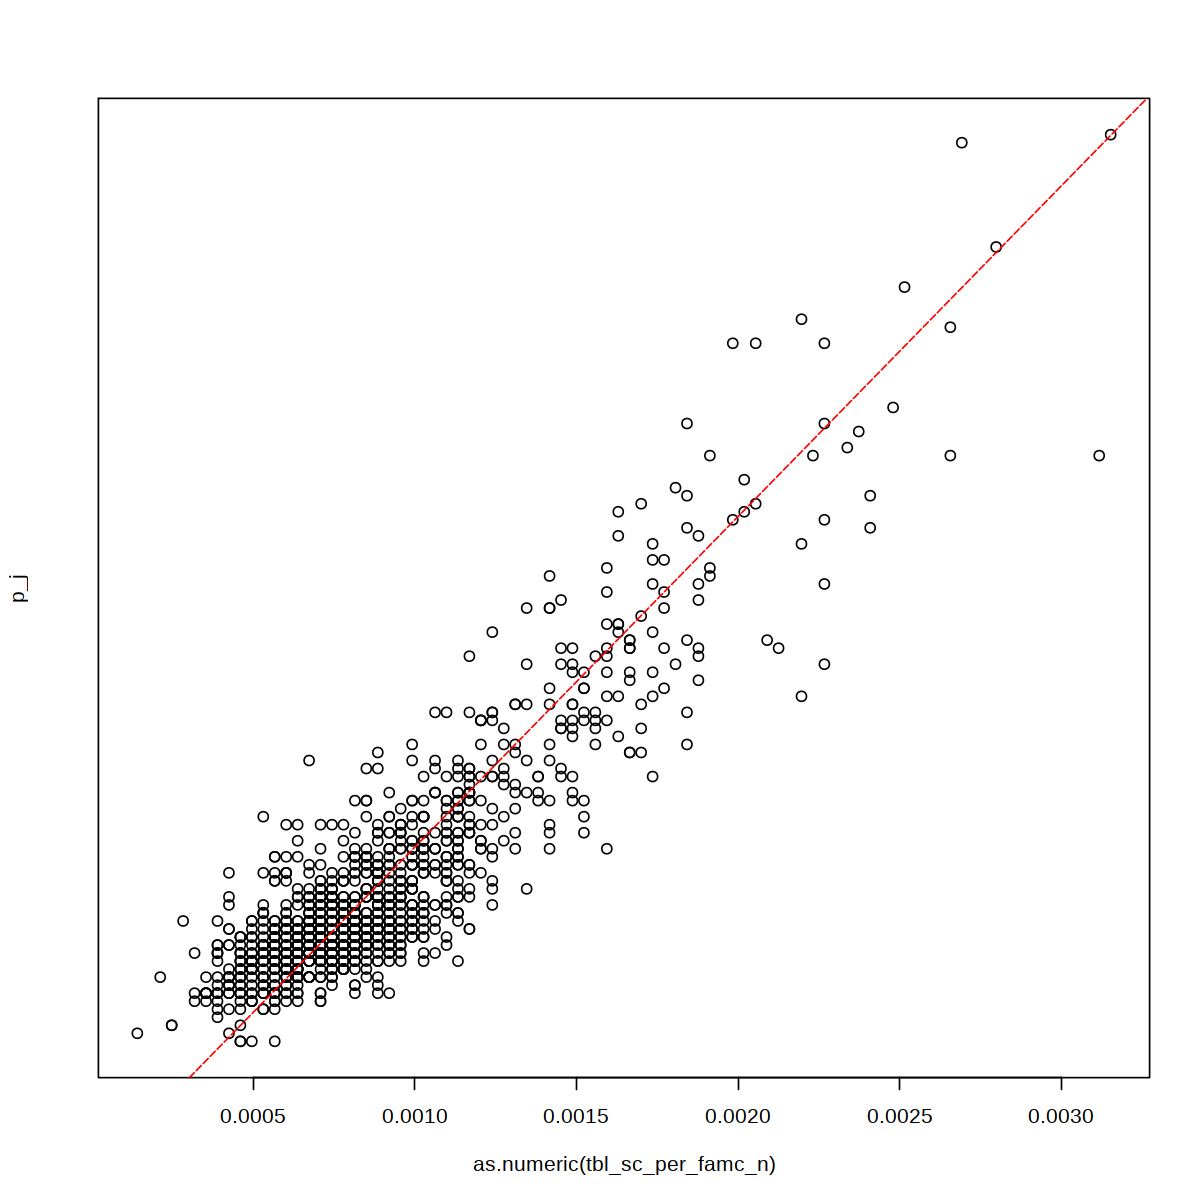

In [309]:
plot(as.numeric(tbl_sc_per_famc_n), p_j)
abline(0,1,lty='longdash',col='red')

In [310]:
## day_mcls <- readRDS(day_mcl_path)
dmcl_vec <- unlist(lapply(seq_along(day_mcls), 
                                function(x,n,i) setNames(paste0(n[[i]], '_', x[[i]]$cor_km$cluster), 
                                                            colnames(x[[i]]$prom_mat)), 
                                                            x = day_mcls, n = names(day_mcls)))

c2amc_2 <- tibble::enframe(sc_clusters_f, name = 'cell', value = 'atac_metacell')
# c2mc_2$atac_metacell <- c2amc_2$atac_metacell[match(c2mc_2$cell, c2amc_2$cell)]

# readr::write_tsv(dplyr::rename(c2mc_2, famc = metacell), "./output/mcatac/c2mc.tsv")

tbl_amc_famc_2 <- table(c2mc$atac_metacell, c2mc$metacell)
tbl_amc_famc_norm <- matrix(tbl_amc_famc_2/rowSums(tbl_amc_famc_2), nrow = nrow(tbl_amc_famc_2), ncol = ncol(tbl_amc_famc_2))
rownames(tbl_amc_famc_norm) <- rownames(tbl_amc_famc_2)
colnames(tbl_amc_famc_norm) <- colnames(tbl_amc_famc_2)

row_annot_2 <- t(tgs_matrix_tapply(matrix(tbl_amc_famc_norm, nrow = nrow(tbl_amc_famc_norm), ncol = ncol(tbl_amc_famc_norm)), mcmd$cell_type, sum))
row_annot_2 <- dplyr::relocate(dplyr::mutate(as.data.frame(row_annot_2), cell_type = colnames(row_annot_2)[apply(row_annot_2, 1, which.max)]), cell_type, .before = Astrocytes)
rownames(row_annot_2) <- rownames(tbl_amc_famc_2)
ord_ra2 <- order(apply(row_annot_2[,cust_st_ord], 1, function(x) sum(x*1:length(x))/sum(x)))
ct_per_amc <- t(tgs_matrix_tapply(matrix(tbl_amc_famc_2, nrow = nrow(tbl_amc_famc_2), ncol = ncol(tbl_amc_famc_2)), mcmd$cell_type, sum))
ct_per_amc <- ct_per_amc/rowSums(ct_per_amc)

row_annot[,colnames(ct_per_amc)] <- ct_per_amc
row_annot <- row_annot[,c('cell_type', cust_st_ord)]
color_key <- unique(mcmd[,c('cell_type', 'color')])
# color_key
for (i in colnames(ct_per_amc)) {
    ann_colors[[i]] <- setNames(colorRampPalette(c('white', color_key$color[match(i, color_key$cell_type)]))(2), c(0,1))
} 

png 
  2

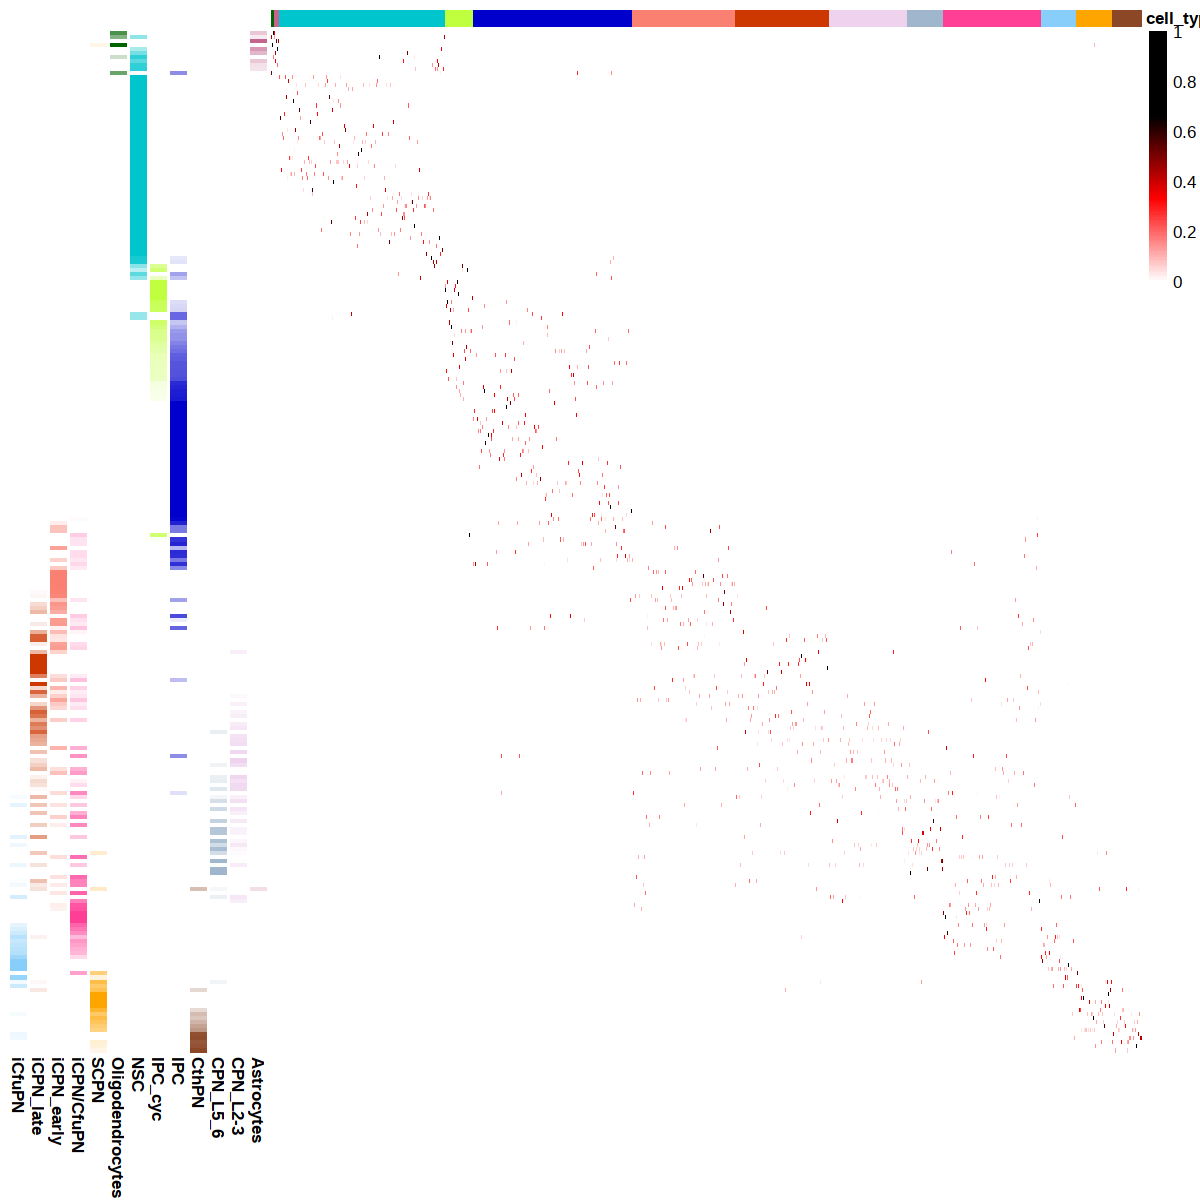

In [311]:
p_flow_mat <- pheatmap(tbl_amc_famc_norm[ord_ra2,cust_mc_ord_st], color = colorRampPalette(c('white', 'red','black', 'black'))(100),
                       cluster_rows = F, cluster_cols = F, show_colnames = F, show_rownames = F, annotation_legend = F,
         annotation_col = col_annot, 
         annotation_row = dplyr::select(row_annot_2, -cell_type),
         annotation_colors = ann_colors
        )

save_pheatmap(p_flow_mat, './output/mcatac/figs/matching_flow_matrix_annot_ct.png', w = 1600, h = 1800, res = 200)

In [312]:
readr::write_tsv(c2mc, "./output/mcatac/c2mc.tsv")

In [ ]:
# cl_all = do.call('c', lapply(seq_along(1:length(day_mcls)), function(dm, i) {dm[[i]]$cor_km$cluster + (i-1)*K}, dm = day_mcls))

# sc_mic_cl_full = data.frame(t(tgs_matrix_tapply(as.matrix(prom_sum@mat), cl_all, mean)))
# mc_from_mcl_flow = as.matrix(sc_mic_cl_full) %*% apply(flow_mat, 2, function(x) x/sum(x))
# # mc_from_mcl_flow = as.matrix(sc_mic_cl_full) %*% flow_mat

# mcl_flow_norm = mc_from_mcl_flow/colSums(mc_from_mcl_flow)

# saveRDS(object = list('flow_mat' = flow_mat, 'cl_all' = cl_all, 'mc_from_mcl_flow' = mc_from_mcl_flow), file = './data/pl_flow_res.rds')

# pp <- pheatmap(slanter::slanted_reorder(flow_mat), color = colorRampPalette(c('black', 'red', 'orange', 'yellow', 'white'))(100),
#          annotation_col = annotation_col, 
#          annotation_colors = ann_colors, 
#          cluster_cols = F, 
#          cluster_rows = F
# )

# save_pheatmap_png(pp, './figs/atac_cortex_matching_flow_mat.png', h = 1600, w = 1600)

# metacells_from_mcl_flow <- function(flow_path, day_mcl_path) {
#     day_mcls <- readRDS(day_mcl_path)
#     flow_mat <- as.matrix(tibble::column_to_rownames(readr::read_tsv(flow_path), 'rowname'))
#     dmcl_vec <- unlist(lapply(seq_along(day_mcls), 
#                                 function(x,n,i) setNames(paste0(n[[i]], '_', x[[i]]$cor_km$cluster), 
#                                                             colnames(x[[i]]$prom_mat)), 
#                                                             x = day_mcls, n = names(day_mcls)))
#     mcls_nums <- unlist(lapply(names(day_mcls), function(d) paste0(d, "_", sort(unique(day_mcls[[1]]$cor_km$cluster)))))
#     dmcl_rename <- match(dmcl_vec, mcls_nums)
#     names(dmcl_rename) <- names(dmcl_vec)
#     flow_mat_norm <- flow_mat/rowSums(flow_mat)
#     flow_mat_cs <- apply(flow_mat_norm, 1, function(x) {
#         y <- setNames(x[which(x > 0)], which(x > 0));
#         ycs <- cumsum(y)
#         names(ycs) <- names(y)
#         return(ycs)
#     })
#     dmcl_rand_nums <- runif(length(dmcl_rename))
#     cell_to_metacell <- as.numeric(unlist(purrr::map2(.x = dmcl_rand_nums, .y = dmcl_rename, .f = function(.x,.y) {
#         names(flow_mat_cs[[.y]])[min(which(flow_mat_cs[[.y]] >= .x))]
#     })))
#     names(cell_to_metacell) <- names(dmcl_vec)
#     return(tibble::enframe(cell_to_metacell, name = 'cell', value = 'metacell'))
# }

# c2mc <- metacells_from_mcl_flow(flow_path = flow_res_path, day_mcl_path = day_mcl_path)

In [77]:
# readr::write_tsv(c2mc, "./output/mcatac/c2mc.tsv")

# day_mcl_path_2 <- file.path(wd, 'output/mcatac/pl_cort_prom_day_mcls_k=50.rds')

# dmcl_2 <- readRDS(day_mcl_path_2)

# dmcl_2[[1]]$

## Plot AMCs vs promoters

In [158]:
# aaa <- readRDS("/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex/output/mcatac/mmc_atac_mcls.rds")


# names(aaa)

# sc_cor_kms <- readRDS('./output//mcatac/microcluster_assignment.RDS')

# # mcl_all_norm <- t(t(as.matrcix(aaa$mcl_all))/Matrix::colSums(aaa$mcl_all))

# mcl_all_norm <- t(t(as.matrix(mcl_all))/Matrix::colSums(mcl_all))

# seq_coords <- misha.ext::convert_10x_peak_names_to_misha_intervals(rownames(mcl_all_norm))

# tss <- gintervals.load('intervs.global.tss')

# prom_peaks <- gintervals.neighbors(seq_coords, tss, mindist = -1e+3, maxdist = 1e+3, maxneighbors = 1)

# dist_peaks <- seq_coords[!(seq_coords$peak_name %in% prom_peaks$peak_name),]

# get_genes_specific_to_mcs <- function(legc, mc_pos = NULL, mc_neg = NULL, cl_vec = NULL) {
#     if (!is.null(mc_pos) && is.null(mc_neg)) {
#         cl_vec <- ifelse(1:ncol(legc) %in% mc_pos, 1, 0)
#     } else if (!is.null(mc_pos) && !is.null(mc_neg)) {
#         if (!(length(intersect(mc_pos, mc_neg)) == 0)) {
#             stop('mc_pos and mc_neg intersect')
#         }
#         legc <- legc[,c(mc_pos, mc_neg)]
#         cl_vec <- c(rep(1, length(mc_pos)), rep(0, length(mc_neg)))
#     }
#     legc_avg <- t(tgs_matrix_tapply(legc, cl_vec, mean))
#     if (ncol(legc_avg) == 2) {
#         diffs <- matrixStats::rowDiffs(legc_avg)
#         rownames(diffs) <- rownames(legc_avg)
#         return(diffs[order( diffs[,1], decreasing = T),])
#     } else {
#         diffs <- t(plyr::laply(1:ncol(legc_avg), function(i) legc_avg[,i] - matrixStats::rowMaxs(legc_avg[,-i]), .parallel = T))
#         colnames(diffs) <- colnames(legc_avg)
#         return(lapply(1:ncol(diffs), function(i) {
#             df <- diffs[which(diffs[,i] > 0.1),]
#             return(df[order(df[,i], decreasing = T),])
#         }))
#     }
# }

# legc <- log2(1e-5+mc_rna@e_gc)

# ct_genes <- get_genes_specific_to_mcs(legc, cl_vec = mcmd$cell_type)

# names(ct_genes) <- sort(unique(mcmd$cell_type))

# lapply(ct_genes, head)

# cts <- c('NSC', 'IPC', 'SCPN', 'CthPN', 'CPN_L2-3', 'CPN_L5_6')

# cell_amc_assignment <- purrr::pmap(.l = list(km = sc_cor_kms, mat = aaa$sc_res, d = 13:18), 
#                                    .f = function(km, mat, d) {y <- tibble::enframe(setNames(colnames(mat[[1]]), km$cluster), name = 'cluster', value = 'cell'); y$day <- d; y$amc <- apply(y[,c('day', 'cluster')], 1, paste0, collapse = '_'); return(y[with(y, order(cluster, cell)),])})

# m_man <- rowMeans(log2(1e-5 + mcl_all_norm))

# sd_man <- matrixStats::rowSds(log2(1e-5 + mcl_all_norm))

# options(repr.plot.width = 18)
# par(mfrow = c(1,2))
# plot(m_man, sd_man)
# smoothScatter(m_man, sd_man)

# prom_peaks_var <- prom_peaks$peak_name[prom_peaks$peak_name %in% rownames(mcl_all_norm)[which(sd_man >= 0.4)] & 
#                                       prom_peaks$geneSymbol %in% unlist(lapply(ct_genes[cts], function(x) head(rownames(x), 250)))]

# length(prom_peaks_var)

# load('./output/mcatac/amc_ann_colors.rda')

# ttt <-load('./output/mcatac/atac_metacell_order_annotation.rda')

# c2mc <- readr::read_tsv('./output/mcatac//c2mc.tsv')

# c2amc <- do.call('rbind', cell_amc_assignment)

# c2amc$famc <- c2mc$metacell[match(c2amc$cell, c2mc$cell)]

# tbl_amc_famc <- as.matrix(table(c2amc$amc, c2amc$famc))

# ct_per_amc <- t(tgs_matrix_tapply(matrix(tbl_amc_famc, nrow = nrow(tbl_amc_famc), ncol = ncol(tbl_amc_famc)), mcmd$cell_type, sum))
# ct_per_amc <- ct_per_amc/rowSums(ct_per_amc)

# row_annot[,colnames(ct_per_amc)] <- ct_per_amc

# row_annot <- row_annot[,c('cell_type', cust_st_ord)]

# head(row_annot)

# color_key <- unique(mcmd[,c('cell_type', 'color')])
# # color_key

# for (i in colnames(ct_per_amc)) {
#     print(i)
#     ann_colors[[i]] <- setNames(colorRampPalette(c('white', color_key$color[match(i, color_key$cell_type)]))(2), c(0,1))
# } 

# pheatmap(tbl_amc_famc[,cust_mc_ord_st],cluster_cols = F, cluster_rows = F, annotation_col = col_annot, annotation_colors= ann_colors, show_colnames = F, show_rownames = F)

# pltmt <- log2(1e-5+mcl_all_norm[prom_peaks_var,order(apply(row_annot[,cust_st_ord], 1, function(x) sum(x*1:length(x))/sum(x)))])

# pheatmap(pltmt, cluster_cols = T, show_rownames = F, 
#          annotation_col = subset(row_annot, select = -cell_type), annotation_colors = ann_colors
#         )

In [ ]:
# # pwms <- parallel::mcmapply(FUN = function(sq, rs) prego::regress_pwm(sequences = sq, response = rs, ), sq = head(seqs_cl), rs = head(clust_ind_ls), mc.cores = 6)
# # sc_cor_neur_kms <- parallel::mclapply(sc_res, function(x) tglkmeans::TGL_kmeans(x$sc_cor_neur, k = 50), mc.cores = 6)

# plot_cor <- function(x,y,km,d) {
#     kmx <- km
#     xx <- x[order(kmx$cluster),order(kmx$cluster)]
#     diag(xx) <- 0
#     yy <- y[order(kmx$cluster),]
#     clrmp = colorRampPalette(c('blue4','white', 'red4','black'))(100)
#     brks <- c(seq(-1,0,l=33),
#               seq(0.01,0.15,l=33),
#               seq(0.16,1,l=34))
#     # H1 <- ComplexHeatmap::Heatmap(xx, name = 'scATAC-scATAC', col = clrmp, 
#     #                         # breaks = brks, 
#     #                         cluster_rows = F, 
#     #                         cluster_columns = F, 
#     #                         show_row_names = F, 
#     #                         show_column_names = F)
#     # column_ha = HeatmapAnnotation(cell_type = mcmd$cell_type[cust_mc_ord_st[cust_mc_ord_st %in% which(day_mat[,as.character(d)] >= 5)]], col = list(cell_type = ann_colors$cell_type), show_annotation_name = F)
#     # H2 <- ComplexHeatmap::Heatmap(yy, name = 'scATAC-mc', top_annotation = column_ha, 
#     #                                 col = clrmp, 
#     #                                 # breaks = brks, 
#     #                                 cluster_rows = F, 
#     #                                 cluster_columns = F, 
#     #                                 show_row_names = F, 
#     #                                 show_column_names = F)
#     # htl <- H1 + H2
#     # png(file.path(wd, 'figs/scatac_cor_per_day_k=50', paste0(d, '_CH.png')), h = 1600, w = 3200)
#     # draw(htl)
#     # dev.off()
#     p1 <- pheatmap(xx, cluster_cols = F, cluster_rows = F, show_colnames = F, show_rownames = F, color = clrmp,silent = T, breaks = brks)
#     p2 <- pheatmap(yy, cluster_cols = F, cluster_rows = F, show_colnames = F, show_rownames = F, color = clrmp,silent = T, breaks = brks,
#                     annotation_col = col_annot,
#                     annotation_colors = ann_colors)
#     # save_pheatmap_png(p1, file.path(wd, 'figs/scatac_cor_per_day_k=50', paste0(d, 'sc-sc.png')))
#     # save_pheatmap_png(p2, file.path(wd, 'figs/scatac_cor_per_day_k=50', paste0(d, 'sc-mc.png')))
#     save_pheatmap_png(p1, file.path(wd, 'figs/scatac_cor_per_day_k=50', paste0(d, 'sc-sc_neuro.png')))
#     save_pheatmap_png(p2, file.path(wd, 'figs/scatac_cor_per_day_k=50', paste0(d, 'sc-mc_neuro.png')))
# }
# sc_cors <- lapply(sc_res, function(x) x$sc_cor)
# sc_cor_mc <- lapply(sc_res, function(x) x$sc_cor_mc)
# sc_neur_cors <- lapply(sc_res, function(x) x$sc_cor_neur)
# sc_neur_cor_mc <- lapply(sc_res, function(x) x$sc_neur_cor_mc)
# aa <- parallel::mcmapply(FUN = function(x,y,km,d) plot_cor(x,y,km,d), 
#                                             x = sc_cors, 
#                                             y = sc_cor_mc, 
#                                             km = sc_cor_kms, 
#                                             d = 13:18, 
#                                             mc.cores = 6)
# bb <- parallel::mcmapply(FUN = function(x,y,km,d) plot_cor(x,y,km,d), x = sc_neur_cors, 
#                                                         y = sc_neur_cor_mc, 
#                                                         km = sc_cor_neur_kms, 
#                                                         d = 13:18, 
#                                                         mc.cores = 6)

# # NUM_EDGE_NODE <- 10
# # day_mcl_path <- file.path(wd, 'output/mcatac/pl_cort_prom_day_mcls_k=50.rds')
# # flow_res_path <- file.path(wd, "output/mcatac/pl_cort_flow_mat.tsv")
# # library(lpsymphony)

# # mcell_add_gene_stat(mat_id = nm, gstat_id = nm, force = F)

# # gstat = scdb_gstat(nm)

# # png(glue::glue('./figs/{nm}_atac_feat.png'), h=1000,w=1000,r=150)
# # plot(log(gstat$ds_mean), gstat$ds_log_varmean)
# # dev.off()

# # x = log(gstat$ds_mean)
# # init_filt = which(x >= -4)
# # y = gstat$ds_log_varmean[init_filt]
# # name_filt = gstat$name
# # x = x[init_filt]

# # xcut = cut(x, breaks = seq(min(x), max(x), l = 50))

# # top_q_inds = lapply(levels(xcut), function(l) {inds = which(xcut == l); 
# #                                   xfilt = y[inds]; 
# #                                   xtop = head(inds[order(xfilt, decreasing = T)], 30); 
# #                                   return(xtop)
# #                                  }
# #       )

# # names(top_q_inds) = levels(xcut)

In [ ]:
# # feats = intersect(rownames(gstat)[init_filt[unlist(top_q_inds)]], rownames(mc_rna@mc_fp))

# # png(glue::glue('./figs/{nm}_atac_feat_select.png'), h=1000,w=1000,r=150)
# # plot(log(gstat$ds_mean), gstat$ds_log_varmean)

# # points(x[sort(unlist(top_q_inds))], y[sort(unlist(top_q_inds))], col = 'red', pch = 16)

# # dev.off()

# ifn1_genes = c('Isg15', 'Wars', 'Ifit1')
# cell_cyc = c('Mki67', 'Pcna', 'Smc4', 'Mcm3', 'Top2a')
# stress = c('Fos', 'Hsp90ab1', 'Hspa1a', 'Hif1a')
# misc = c('Xist', 'Tsix')
# star_genes = c(ifn1_genes, cell_cyc, stress, misc)
# star_genes = c(star_genes, c(grep('Mmc', feats, v=T),
#                             grep('^Smc\\d', feats, v=T),
#                             grep('^Cdk', feats, v=T),
#                             grep('^Ccn', feats, v=T),
#                              grep('^Ube', feats, v=T),
#                              grep('^Rpl', feats, v=T),
#                               grep('^Rps', feats, v=T)
#                             )
#               )

# feats_filt = unique(feats[!(feats %in% star_genes)])
# length(feats_filt)
# length(feats)

# days = tail(unique(prom_sum@cell_metadata$day), -1)
# days

# day_mat = cbind(sapply(days, function(d) apply(mcmd[,grep(d, colnames(mcmd))], 1, sum)))

# day_mat = t(apply(day_mat, 1, function(x) x/sum(x)))

# mcmd= tibble::tibble(cbind(mcmd, day_mat))
# colnames(mcmd)[colnames(mcmd) %in% 1:6] = 13:18
# head(mcmd)
# prom_mat <- prom_sum@mat
# cs <- Matrix::colSums(prom_mat)

# prom_mat_ds <- scm_downsamp(prom_mat, min(cs))

# make_day_mcl = function(d) {
#     # prom_sum = scdb_mat(glue::glue('prom_cort_day_{d}'))
#     inds_in = rownames(prom_sum@cell_metadata)[prom_sum@cell_metadata$day == d]
#     inds_in = inds_in[inds_in %in% colnames(prom_sum@mat)]
#     prom_mat_here = prom_mat_ds[,inds_in]
#     cor_mat = tgs_cor(as.matrix(prom_mat_here[feats_filt,]), as.matrix(mc_rna@mc_fp[feats_filt,]), spearman = T)
#     cor_km = tglkmeans::TGL_kmeans(df = cor_mat, k = K_CL_PER_DAY, seed = SEED)
#     sc_mic_cl = data.frame(t(tgs_matrix_tapply(as.matrix(prom_mat_here), cor_km$cluster, mean)))
#     cor_mic_cl = tgs_cor(x = as.matrix(sc_mic_cl[feats_filt,]), y = mc_rna@mc_fp[feats_filt,], spearman = T)
#     return(list('cor_mic_cl' = cor_mic_cl, 'sc_mic_cl' = sc_mic_cl, 'cor_km' = cor_km, 'cor_mat' = cor_mat, 'prom_mat' = prom_mat_here))
# }

# day_mcls = parallel::mclapply(days, make_day_mcl, mc.cores = length(days))
# names(day_mcls) = days

# # saveRDS(day_mcls, './data/pl_cort_prom_day_mcls.rds')
# # saveRDS(day_mcls, './data/pl_cort_prom_day_mcls_k=100.rds')
# saveRDS(day_mcls, day_mcl_path)
# # day_mcls = readRDS('./data/pl_cort_prom_day_mcls.rds')

# # day_mcls = readRDS('./data/pl_cort_prom_day_mcls_k=100.rds')
# day_mcls = readRDS(day_mcl_path)

# color_key = unique(mcmd[,c('cell_type', 'color')])
# annotation_col = data.frame(cell_type = mcmd$cell_type)
# rownames(annotation_col) = mcmd$metacell
# ann_colors = list(cell_type = setNames(color_key$color, color_key$cell_type))

# cust_st_ord = c('OPCs','Astrocytes','NSC','IPC_cyc', 'IPC', 'iCPN_early','iCPN_late',
#                       'CPN_L2-3','CPN_L5_6','iCPN/CfuPN','iCfuPN','SCPN','CthPN')
# cust_mc_ord_st = unlist(lapply(cust_st_ord, function(st) setNames(sort(mcmd$metacell[mcmd$cell_type == st]), 
#                                                                   rep(st, length(which(mcmd$cell_type == st))))))
# # cust_mc_ord_st

# day_mcl_fig_dir = './figs/pl_cort_day_mcl'
# if (!dir.exists(day_mcl_fig_dir)) {dir.create(day_mcl_fig_dir)}

# plot_mc_pheatmap = function(cor_km, cor_mat, cor_mic_cl, day) {
#                 p = pheatmap::pheatmap(cor_mic_cl[,cust_mc_ord_st], cluster_cols = F, cluster_rows = F, silent = T, fontsize = 18, annotation_legend = F,
#                                    main = glue::glue('day {day}'), annotation_col = annotation_col, 
#                                    annotation_colors = ann_colors,
#                         color = colorRampPalette(c('blue','green', 'white','yellow','red'))(1000))
#                 save_pheatmap_png(p, paste0(day_mcl_fig_dir, '/', day, '.png'), height = 2500, width = 2500, res = 150)
# }

# lapply(seq_along(day_mcls), function(x,n,i) {
#     plot_mc_pheatmap(x[[i]]$cor_km, x[[i]]$cor_mat, x[[i]]$cor_mic_cl, n[[i]])}, 
#        x = day_mcls, n = names(day_mcls)
#       )